# Explortory Data Analysis 

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [52]:
# Setting the path
data_path = Path('/Users/Priyanka/Documents/Internship-Internmo/Zomato_BI_Project/data')

In [53]:
# loading the cleaned datasets
cities = pd.read_parquet(data_path /'cleaned' / 'cities_cleaned.parquet')
customer_feedback = pd.read_parquet(data_path /'cleaned' / 'customer_feedback_cleaned.parquet')
customers = pd.read_parquet(data_path /'cleaned' / 'customers_cleaned.parquet')
delivery_partners = pd.read_parquet(data_path /'cleaned' / 'delivery_partners_cleaned.parquet')
menu = pd.read_parquet(data_path /'cleaned' / 'menu_cleaned.parquet')
order_items = pd.read_parquet(data_path /'cleaned' / 'order_items_cleaned.parquet')
orders = pd.read_parquet(data_path /'cleaned' / 'orders_cleaned.parquet')
payments = pd.read_parquet(data_path /'cleaned' / 'payments_cleaned.parquet')
promotions = pd.read_parquet(data_path /'cleaned' / 'promotions_cleaned.parquet')
restaurants = pd.read_parquet(data_path /'cleaned' / 'restaurants_cleaned.parquet')
traffic = pd.read_parquet(data_path /'cleaned' / 'traffic_cleaned.parquet')
weather = pd.read_parquet(data_path /'cleaned' / 'weather_cleaned.parquet')

# Load the engineered features dataset
df_feat = pd.read_parquet(data_path / 'processed' / 'featured_orders.parquet')



In [54]:
# df_feat inherits `str` dtype for several numeric columns (features.py never
# casts them, only FinalAmount gets pd.to_numeric there) - fix that once here
# so every chart below can rely on real numeric dtypes.
numeric_cols = ['DeliveryTimeMinutes', 'FoodCost', 'DeliveryFee', 'Discount', 'GST']
for col in numeric_cols:
    df_feat[col] = pd.to_numeric(df_feat[col], errors='coerce')
    orders[col] = pd.to_numeric(orders[col], errors='coerce')

print(cities.columns.tolist())


['CityID', 'City', 'Population', 'Region', 'AverageIncome']


In [55]:
print("Cleaned Orders Count:", len(orders))
print("Featured Orders Count:", len(df_feat))
print(orders["OrderStatus"].value_counts())

missing_orders = set(orders["OrderID"].astype(str)) - set(
    df_feat["OrderID"].astype(str)
)
print("Orders dropped during Feature Engineering:", len(missing_orders))


Cleaned Orders Count: 20475
Featured Orders Count: 20475
OrderStatus
Delivered             11390
Cancelled              4569
Food Not Delivered     2362
Delivered Late         2154
Name: count, dtype: int64
Orders dropped during Feature Engineering: 0


In [56]:
# Palette Definition
ZOMATO_RED = "#E23744"
ZOMATO_DARK_RED = "#CB202D"
CHARCOAL = "#2D2D2D"
NEUTRAL_BOX = "#F4F4F2"
NEUTRAL_GREY = "#E0E0E0"

#Setting the style for seaborn plots
sns.set_theme(style="darkgrid", palette="pastel")

# Apply Palette Globally to Seaborn
zomato_palette = [
    ZOMATO_RED,
    ZOMATO_DARK_RED,
    CHARCOAL,
    NEUTRAL_GREY,
    NEUTRAL_BOX,
]
sns.set_palette(sns.color_palette(zomato_palette))

### Peak Hours & Weekend Orders (On Engineered Features)

/var/folders/14/vwm12jsj6k54dqpcrph9h29w0000gp/T/ipykernel_91746/2640236629.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels(['Off-Peak', 'Peak Hours'])


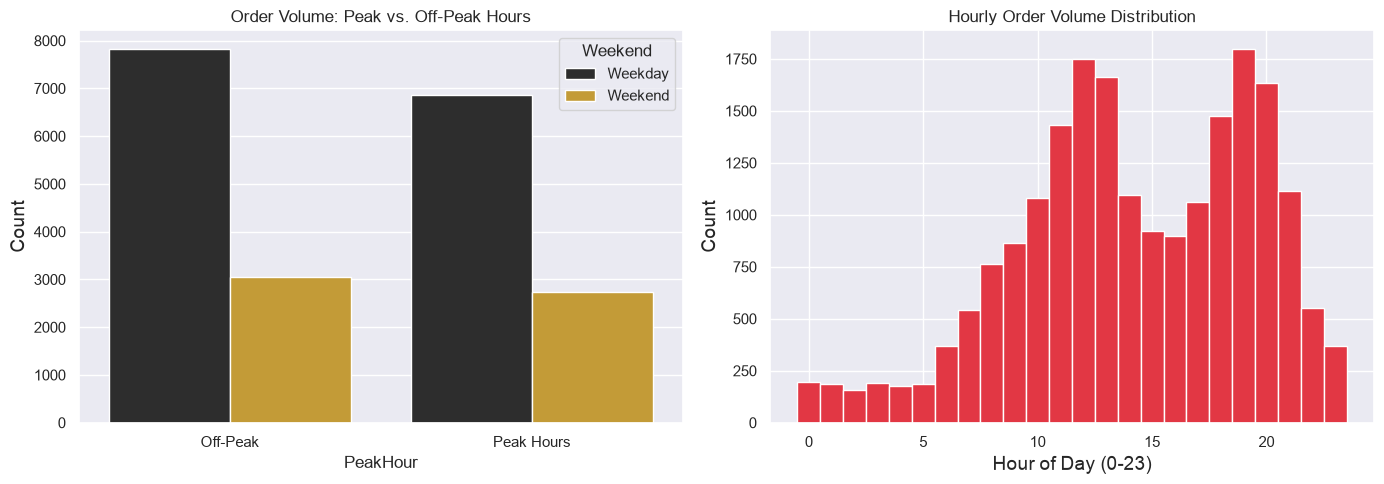

In [57]:
# Quick look at peak hours & weekend orders using the engineered PeakHour / WeekendOrder flags
peak_dist = df_feat['PeakHour'].value_counts(normalize=True) * 100
weekend_dist = df_feat['WeekendOrder'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(
    data=df_feat,
    x='PeakHour',
    hue='WeekendOrder',
    palette=[CHARCOAL, 'goldenrod'],
    ax=axes[0],
)
axes[0].set_title('Order Volume: Peak vs. Off-Peak Hours')
axes[0].set_xticklabels(['Off-Peak', 'Peak Hours'])
axes[0].set_ylabel('Count', fontsize=14)
axes[0].legend(title='Weekend', labels=['Weekday', 'Weekend'])

sns.histplot(
    data=df_feat, x='OrderHour', bins=24, discrete=True, alpha=1, color=ZOMATO_RED, ax=axes[1]
)
axes[1].set_title('Hourly Order Volume Distribution')
axes[1].set_xlabel('Hour of Day (0-23)', fontsize=14)
axes[1].set_ylabel('Count', fontsize=14)


plt.tight_layout()
plt.show()


Output : Confirms the same story from the hourly breakdown below, just from the engineered PeakHour/WeekendOrder flags directly.

In [58]:
# Standardize Datetime Types
orders["OrderDate"] = pd.to_datetime(orders["OrderDate"], errors="coerce")
orders["OrderTime"] = pd.to_datetime(
    orders["OrderTime"], format="%H:%M:%S", errors="coerce"
)

In [59]:
#Extracting time & date features from the 'order_time' and 'order_date' column in the orders dataset
orders['Hour'] = orders['OrderTime'].dt.hour
orders['DayOfWeek'] = orders['OrderDate'].dt.day_name()
orders['IsWeekend'] = orders['DayOfWeek'].isin(['Saturday', 'Sunday'])
orders['DayType'] = np.where(orders['IsWeekend'], 'Weekend', 'Weekday')
orders['Month'] = orders['OrderDate'].dt.month

In [60]:
print("Hour:")
print(orders['Hour'].head())
print("Day of Week:")
print(orders['DayOfWeek'].head())
print("Is Weekend:")
print(orders['IsWeekend'].head())
print("Day Type:")
print(orders['DayType'].head())

Hour:
0    11
1    10
2    19
3     0
4    12
Name: Hour, dtype: int32
Day of Week:
0    Saturday
1    Saturday
2     Tuesday
3    Saturday
4      Sunday
Name: DayOfWeek, dtype: str
Is Weekend:
0     True
1     True
2    False
3     True
4     True
Name: IsWeekend, dtype: bool
Day Type:
0    Weekend
1    Weekend
2    Weekday
3    Weekend
4    Weekend
Name: DayType, dtype: str


In [61]:
#Peak ordering hours analysis
hourly_summary = (
orders.groupby('Hour')['OrderID']
    .count()
    .reset_index(name = 'TotalOrders')
    .sort_values(by='TotalOrders', ascending=False)
)

In [62]:
print('Top 5 Peak Ordering Hours:')
print(hourly_summary.head(5).to_string(index=False))

Top 5 Peak Ordering Hours:
 Hour  TotalOrders
   19         1797
   12         1749
   13         1663
   20         1632
   18         1474


In [63]:
# pull cuisine name in so we can group revenue by it
df_ord_rest = orders.merge(restaurants[['RestaurantID','RestaurantName','Cuisine']],
                        on='RestaurantID', how='inner')


In [64]:
top_restaurants = (
    df_ord_rest.groupby('RestaurantName')['FinalAmount']
    .sum()
    .reset_index(name='TotalRevenue')
    .sort_values(by='TotalRevenue', ascending=False)
    .head(10)
)
print("Top 10 Restaurants by Revenue:")
print(top_restaurants.to_string(index=False))


Top 10 Restaurants by Revenue:
RestaurantName  TotalRevenue
     The House     149972.25
 Grand Kitchen     127016.25
    Curry Cafe     126997.15
  Green Corner     126284.95
   Urban House     123242.45
   Urban Point     121843.90
 Curry Kitchen     119570.35
     The Point     118205.30
   Blue Treats     116701.45
   Urban Diner     114509.50


Output : The top three restaurants (The House, Grand Kitchen, Curry Cafe) are all generating similar revenue in the 1.49L, 1.27L and 1.26L range.

In [65]:
top_cuisines = (
    df_ord_rest.groupby('Cuisine')['FinalAmount']
    .sum()
    .reset_index(name='TotalRevenue')
    .sort_values(by='TotalRevenue', ascending=False)
    .head(10)
)
print("Top 10 Cuisines by Revenue:")
print(top_cuisines.to_string(index=False))


Top 10 Cuisines by Revenue:
     Cuisine  TotalRevenue
South Indian     551636.75
   Fast Food     511595.15
Healthy Food     488655.85
 Street Food     459435.90
    Desserts     448641.30
       Sushi     429632.30
 Continental     427730.70
       Pizza     427416.70
     Seafood     414767.75
     Mexican     405212.40


Output : South Indian, Fast Food and Healthy Food lead cuisine revenue 5.5L, 5.1L, 4.9 respectively. So South Indian is the highest revenue generating cuisine so far

In [66]:
df_ord_rest['YearMonth'] = df_ord_rest['OrderDate'].dt.to_period('M')
cuisine_monthly = (
    df_ord_rest.groupby(['YearMonth', 'Cuisine'])['FinalAmount']
    .sum()
    .unstack(fill_value=0)
)
print("Monthly Revenue Trend by Cuisine (Year-Month):")
print(cuisine_monthly)


Monthly Revenue Trend by Cuisine (Year-Month):
Cuisine      Bakery       Bbq   Biryani   Burgers   Chinese  Continental  \
YearMonth                                                                  
2023-01    17381.70  16768.55  21892.25  15553.25  14982.10     17118.10   
2023-02    17011.20  18121.65  23604.50  11462.20  13337.95     18284.65   
2023-03    13634.95  18664.00  20781.85  18313.65  15711.85     14807.60   
2023-04    16534.10  17277.60  14938.25  17839.60  12919.90     17052.55   
2023-05     8494.85  18629.00  12503.35  20616.90  12883.45     22567.20   
2023-06     7879.80  17352.05  13247.05  21670.50  17018.00     16545.20   
2023-07    13414.30  17135.25  11565.50  13546.70  14891.80     22116.85   
2023-08    20908.70  21180.55  15818.80  18681.55  16317.45     14817.30   
2023-09    17813.95  18591.75  14842.05  15609.60  15188.35     16988.65   
2023-10    13460.85  15144.20  16108.45  14231.05  14602.60     15706.55   
2023-11    14409.65  17594.65  16661.90  

In [67]:
df_ord_rest['YearQuarter'] = df_ord_rest['OrderDate'].dt.to_period('Q')
cuisine_quarterly = (
    df_ord_rest.groupby(['YearQuarter', 'Cuisine'])['FinalAmount']
    .sum()
    .unstack(fill_value=0)
)
top_5_cuisines = (
    df_ord_rest.groupby('Cuisine')['FinalAmount']
    .sum()
    .nlargest(5)
    .index.tolist()
)
print("Quarterly Revenue Matrix (Top 5 cuisines:)")
print(cuisine_quarterly[top_5_cuisines])


Quarterly Revenue Matrix (Top 5 cuisines:)
Cuisine      South Indian  Fast Food  Healthy Food  Street Food  Desserts
YearQuarter                                                              
2023Q1           64327.75   65252.20      59292.05     52389.55  50177.85
2023Q2           72245.40   61507.05      58018.00     56269.55  59080.20
2023Q3           78822.35   63633.10      76524.00     63887.55  57732.10
2023Q4           70491.65   69371.45      57985.60     60476.65  64017.35
2024Q1           67247.55   54794.75      62534.75     62724.50  60605.50
2024Q2           65340.35   74453.35      57074.00     40746.80  51762.90
2024Q3           72177.85   60126.55      53326.15     54167.95  55206.30
2024Q4           60983.85   62456.70      63901.30     68773.35  50059.10


Output: 
- It is observed that in Quarter 1 of 2023 south indian and fast food generated similar highest revenues and Q2 & Q3 of 2023, South indian cuisine supplied with most revenue, followed with Q4 South indian and fast food were similar.
- In Q1 & Q3 of 2024, South Indian food was more profitable for the company, in Q2 Fast food was highest revenue generating but interestingly, in Q4 Street food surpassed but the in demand cuisines and generated the highest revenue. 

### Top Revenue Trend for Restaurants & Cuisines

/var/folders/14/vwm12jsj6k54dqpcrph9h29w0000gp/T/ipykernel_91746/2968732262.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


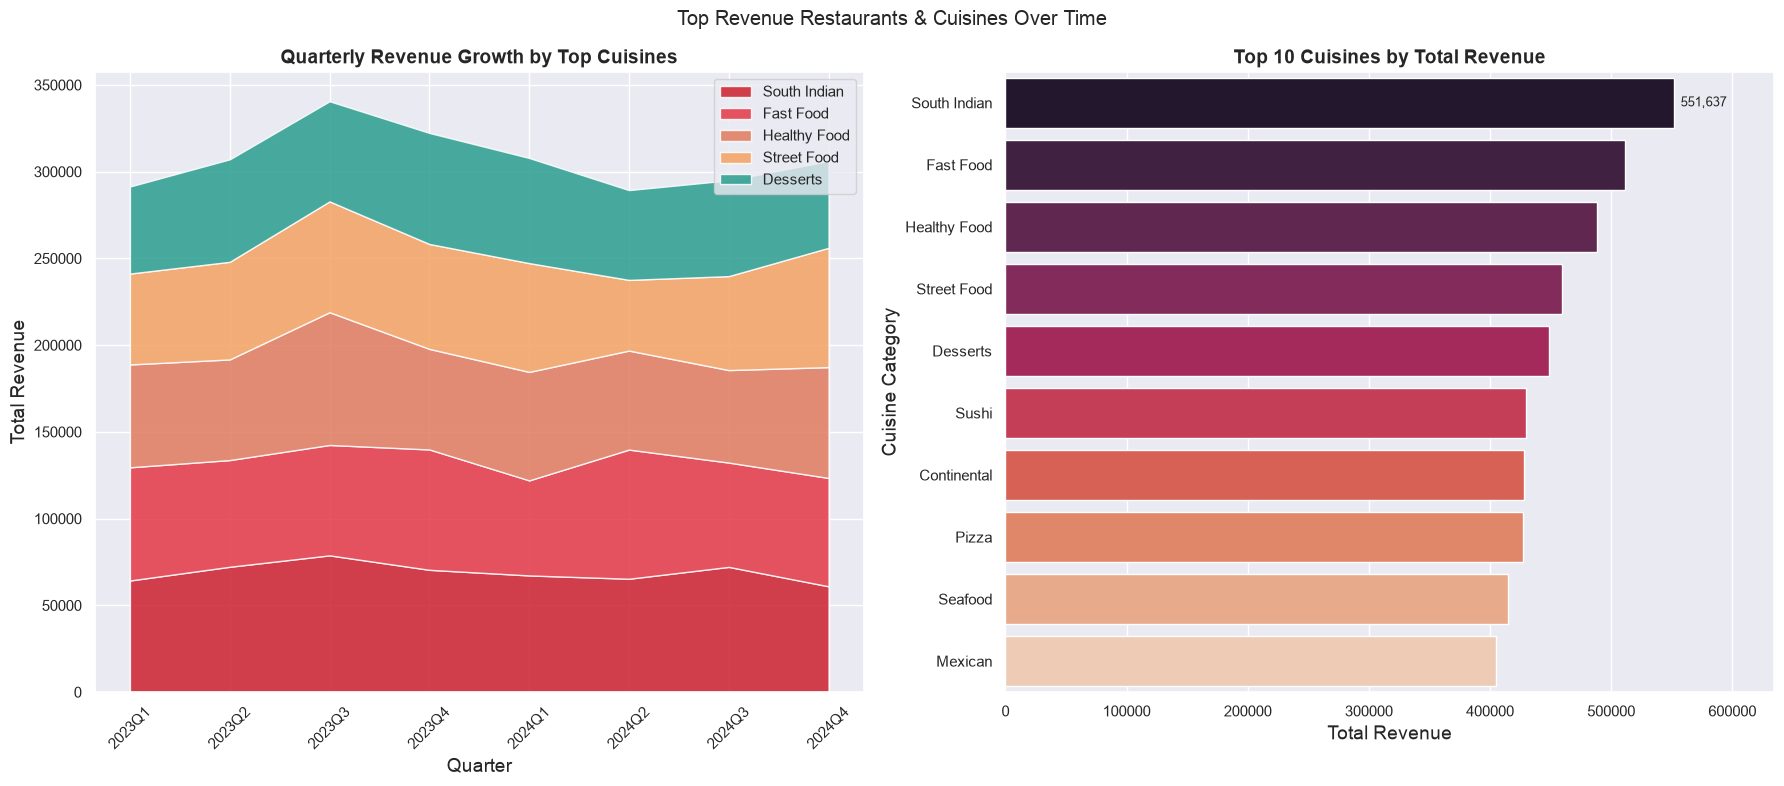

In [68]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('Top Revenue Restaurants & Cuisines Over Time')

# 1. Quarterly Stacked Area Chart
quarterly_top5 = cuisine_quarterly[top_5_cuisines]
colors = [ZOMATO_DARK_RED, ZOMATO_RED, '#E07A5F', '#F4A261', '#2A9D8F']

axes[0].stackplot(
    quarterly_top5.index.astype(str),
    quarterly_top5.T,
    labels=top_5_cuisines,
    colors=colors,
    alpha=0.85,
)
axes[0].set_title('Quarterly Revenue Growth by Top Cuisines', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Quarter',fontsize=14)
axes[0].set_ylabel('Total Revenue',fontsize=14)
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(loc='upper right')

# 2. Top 10 Cuisines Bar Chart
sns.barplot(
    data=top_cuisines,
    x='TotalRevenue',
    y='Cuisine',
    palette= 'rocket',
    ax=axes[1],
)

axes[1].bar_label(axes[1].containers[0], fmt='{:,.0f}', padding=5, fontsize=9)
axes[1].set_xlim(0, top_cuisines['TotalRevenue'].max() * 1.15)
axes[1].set_title('Top 10 Cuisines by Total Revenue', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Total Revenue',fontsize=14)
axes[1].set_ylabel('Cuisine Category',fontsize=14)

plt.tight_layout()
plt.show()

Output: 
- It is observed that overall cumulative revenue across these top cuisines peaked in 2023Q3 at approximately 340,000.
- Total revenue experienced a slight contraction through 2023Q4 and 2024Q2 (dipping to around 2,88,000) before showing modest recovery in 2024Q4 (reaching back above 3,00,000).

### Peak Ordering Hours & Weekday vs. Weekend Demand Patterns

In [69]:
# Hourly volume matrix (Hour x DayType)
hourly_pivot = (
    orders.groupby(['Hour', 'DayType']).size().unstack(fill_value=0)
)

# Daily Order Volume by Day of Week
days_order = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday',
]
daily_volume = (
    orders.groupby('DayOfWeek').size().reindex(days_order).reset_index(name='OrderCount')
)
print("Hourly Order Volume Matrix (Weekday vs Weekend)")
print(hourly_pivot.tail(12))

print("\nDaily Order Volume Summary")
print(daily_volume.to_string(index=False))

peak_weekday_hour = hourly_pivot['Weekday'].idxmax()
peak_weekend_hour = hourly_pivot['Weekend'].idxmax()
print(f'\n✓ Weekday Peak Hour: {peak_weekday_hour}:00')
print(f'✓ Weekend Peak Hour: {peak_weekend_hour}:00')

Hourly Order Volume Matrix (Weekday vs Weekend)
DayType  Weekday  Weekend
Hour                     
12          1232      517
13          1198      465
14           809      287
15           662      260
16           644      256
17           760      300
18          1057      417
19          1269      528
20          1151      481
21           808      305
22           393      157
23           267      101

Daily Order Volume Summary
DayOfWeek  OrderCount
   Monday        2872
  Tuesday        2868
Wednesday        2991
 Thursday        2975
   Friday        2976
 Saturday        2904
   Sunday        2889

✓ Weekday Peak Hour: 19:00
✓ Weekend Peak Hour: 19:00


Output: Both weekdays and weekends the peak hours remain 7pm followed closely by 12pm as second most peak hour.

### Peak Ordering Hours Visualization

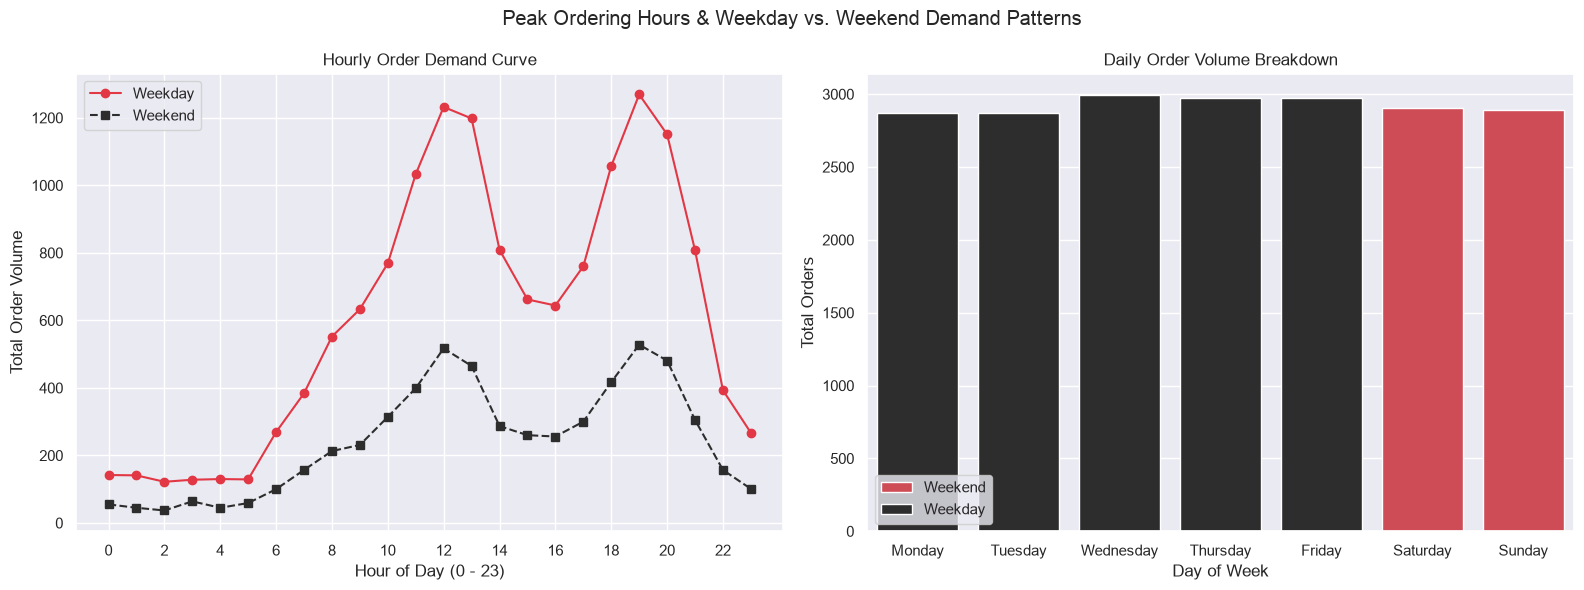

In [70]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Peak Ordering Hours & Weekday vs. Weekend Demand Patterns')

# 1. Hourly demand curves
axes[0].plot(hourly_pivot.index, hourly_pivot['Weekday'], 'o-', color=ZOMATO_RED, label='Weekday')
axes[0].plot(hourly_pivot.index, hourly_pivot['Weekend'], 's--', color=CHARCOAL, label='Weekend')

axes[0].set_title('Hourly Order Demand Curve')
axes[0].set_xlabel('Hour of Day (0 - 23)')
axes[0].set_ylabel('Total Order Volume')
axes[0].set_xticks(range(0, 24, 2))
axes[0].legend(loc='upper left')

# 2. Daily order volume
sns.countplot(
    data=orders,
    x='DayOfWeek',
    order=days_order,
    hue='DayType',
    palette=[ZOMATO_RED, CHARCOAL],
    ax=axes[1],
)
axes[1].set_title('Daily Order Volume Breakdown')
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Total Orders')
axes[1].tick_params(axis='x')
axes[1].legend(loc='lower left')

plt.tight_layout()
plt.show()

### Delivery Time Distribution & City Variance

In [71]:
# Merge orders with traffic and weather 
orders_tw = orders.copy()
q1_val = orders_tw['DeliveryTimeMinutes'].quantile(0.25)
q3_val = orders_tw['DeliveryTimeMinutes'].quantile(0.75)
iqr = q3_val - q1_val
cap_99 = orders_tw['DeliveryTimeMinutes'].quantile(0.99)

# Cap extreme delivery times at 99th percentile (preserving record count)
orders_tw['DeliveryTimeCapped'] = orders_tw['DeliveryTimeMinutes'].clip(
    upper=cap_99
)
print("Delivery Outlier Summary:")
print(
    f'Q1: {q1_val:.1f} mins | Q3: {q3_val:.1f} mins | IQR: {iqr:.1f} mins'
)
print(f'99th Percentile Cap Value: {cap_99:.1f} mins')
print(
    f'Max Raw Delivery Time: {orders_tw["DeliveryTimeMinutes"].max():.1f} mins'
)
print(
    f'Max Capped Delivery Time: {orders_tw["DeliveryTimeCapped"].max():.1f} mins'
)

Delivery Outlier Summary:
Q1: 28.0 mins | Q3: 43.0 mins | IQR: 15.0 mins
99th Percentile Cap Value: 89.0 mins
Max Raw Delivery Time: 180.0 mins
Max Capped Delivery Time: 89.0 mins


In [72]:
# Join City directly from customers if not present in orders
if 'City' not in orders_tw.columns and 'CustomerID' in orders_tw.columns:
  orders_tw = orders_tw.merge(
      customers[['CustomerID', 'City']], on='CustomerID', how='left'
  )
  


In [73]:
# Calculate Stats by City
city_delivery_stats = (
    orders_tw.groupby('City')['DeliveryTimeCapped']
    .agg(['mean', 'median', 'std', 'count'])
    .sort_values(by='mean', ascending=False)
    
)

print('Delivery time statistics by City:')
print(city_delivery_stats)

Delivery time statistics by City:
                    mean  median        std  count
City                                              
Bengaluru      37.873737    36.0  15.120894    792
Kolkata        37.794785    36.0  14.634396    882
Visakhapatnam  37.726535    36.0  14.360193    863
Patna          37.725161    35.0  15.345397    775
Nagpur         37.622028    36.0  15.065848    799
Coimbatore     37.552752    36.0  13.895442    872
Ahmedabad      37.452903    36.0  14.707749    775
Chandigarh     37.440503    35.0  14.967296    874
Ludhiana       37.394089    34.0  15.210398    812
Kochi           37.29304    36.0  14.173552    819
Nashik          37.28169    35.0  14.700777    781
Bhubaneswar    37.249465    35.0   15.64939    934
Hyderabad      37.248507    34.0  14.643381    837
Vadodara       37.063473    35.0  14.180814    835
Pune             37.0447    35.0  13.756349    783
Bhopal         36.981179    35.0  14.409862    797
Lucknow        36.865885    35.0  14.783055    7

#### Visualization of Delivery Time Distribution & City Variance

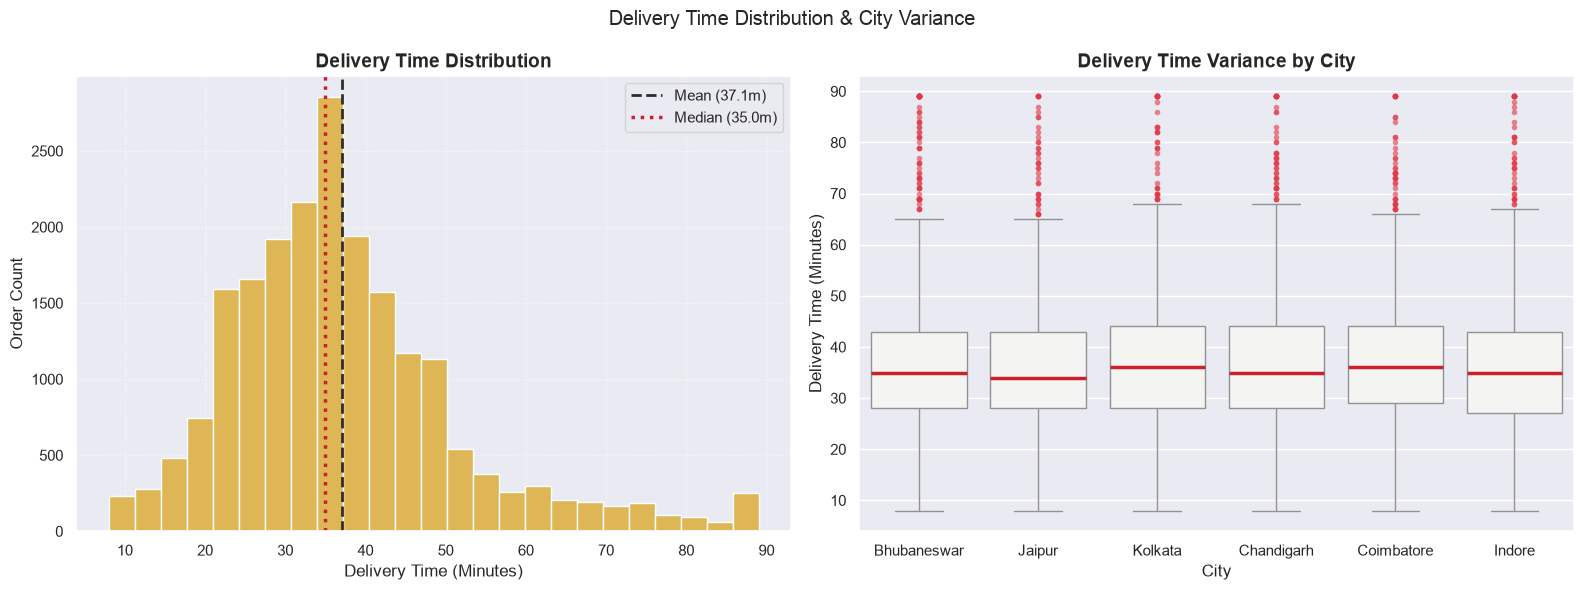

In [74]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Delivery Time Distribution & City Variance')

# 1. Delivery time histogram
sns.histplot(
    data=orders_tw,
    x='DeliveryTimeCapped',
    bins=25,
    color='goldenrod',
    ax=axes[0],
)

mean_dt = orders_tw['DeliveryTimeCapped'].mean()
median_dt = orders_tw['DeliveryTimeCapped'].median()

axes[0].axvline(
    mean_dt,
    color=CHARCOAL,
    ls='--',
    lw=2,
    label=f'Mean ({mean_dt:.1f}m)',
)
axes[0].axvline(
    median_dt,
    color=ZOMATO_DARK_RED,
    ls=':',
    lw=2.5,
    label=f'Median ({median_dt:.1f}m)',
)

axes[0].set_title('Delivery Time Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Delivery Time (Minutes)')
axes[0].set_ylabel('Order Count')
axes[0].grid(True, ls=':', alpha=0.6)
axes[0].legend(loc='upper right')

# 2. Boxplot by Top Cities
top_cities = orders_tw['City'].value_counts().head(6).index
top_city_data = orders_tw[orders_tw['City'].isin(top_cities)]

sns.boxplot(
    data=top_city_data,
    x='City',
    y='DeliveryTimeCapped',
    order=top_cities,
    color=NEUTRAL_BOX,
    ax=axes[1],
    flierprops={'markerfacecolor': ZOMATO_RED, 'markeredgecolor': 'none', 'alpha': 0.6, 'markersize': 4},
)

# Custom median line color to match your original styling
for line in axes[1].lines[4::6]:
    line.set_color(ZOMATO_DARK_RED)
    line.set_linewidth(2.5)

axes[1].set_title('Delivery Time Variance by City', fontsize=14, fontweight='bold')
axes[1].set_xlabel('City')
axes[1].set_ylabel('Delivery Time (Minutes)')

plt.tight_layout()
plt.show()

Output : 
- The mean (37.1m) sitting above the median (35m) means a right-skewed distribution. A tail of badly delayed orders pulling the average up, not a uniformly slow system. The 85-90min bump looks like the delivery-time cap kicking in on a batch of delayed orders. 
- What stands out most is every city shows the same 8-65min range and the same long upper-outlier tail — this looks like a structural delay pattern and not a city-specific problem.

### Basket Size & Membership

In [75]:
orders_cm = orders.copy()
if 'Membership' not in orders_cm.columns and 'CustomerID' in orders_cm.columns:
    orders_cm = orders_cm.merge(
        customers[['CustomerID', 'Membership']], on='CustomerID', how='left'
    )


In [76]:

# Fallback default if Membership is unassigned
orders_cm['Membership'] = orders_cm['Membership'].fillna('Standard')

# 2. Join Order Items to aggregate Item Count per Order (Basket Size)
if 'OrderID' in order_items.columns:
    basket_counts = (
        order_items.groupby('OrderID')
        .size()
        .reset_index(name='ItemsPerOrder')
    )
    orders_cm = orders_cm.merge(basket_counts, on='OrderID', how='left')
    orders_cm['ItemsPerOrder'] = orders_cm['ItemsPerOrder'].fillna(1).astype(int)

# 3. Extract Tier Order by Frequency (Basic, Gold, Zomato Pro, Standard)
tier_order = (
    orders_cm['Membership'].value_counts().index.tolist()
)

In [77]:

# Summary Stats by Membership Tier
tier_summary = (
    orders_cm.groupby('Membership')
    .agg(
        AverageOrderValue=('FinalAmount', 'mean'),
        MedianOrderValue=('FinalAmount', 'median'),
        AvgItemsPerOrder=('ItemsPerOrder', 'mean'),
        TotalOrders=('OrderID', 'count')
    )
    .reset_index()
)

print("Membership tier basket economics:")
print(tier_summary.to_string(index=False))

Membership tier basket economics:
Membership  AverageOrderValue  MedianOrderValue  AvgItemsPerOrder  TotalOrders
     Basic         392.334979           383.775          2.071498        12266
      Gold         391.427081           382.600          2.057172         3953
Zomato Pro         390.199248           381.750          2.072368         4256


#### Visualization of Membership Tier-wise Basket Size

/var/folders/14/vwm12jsj6k54dqpcrph9h29w0000gp/T/ipykernel_91746/1703129625.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


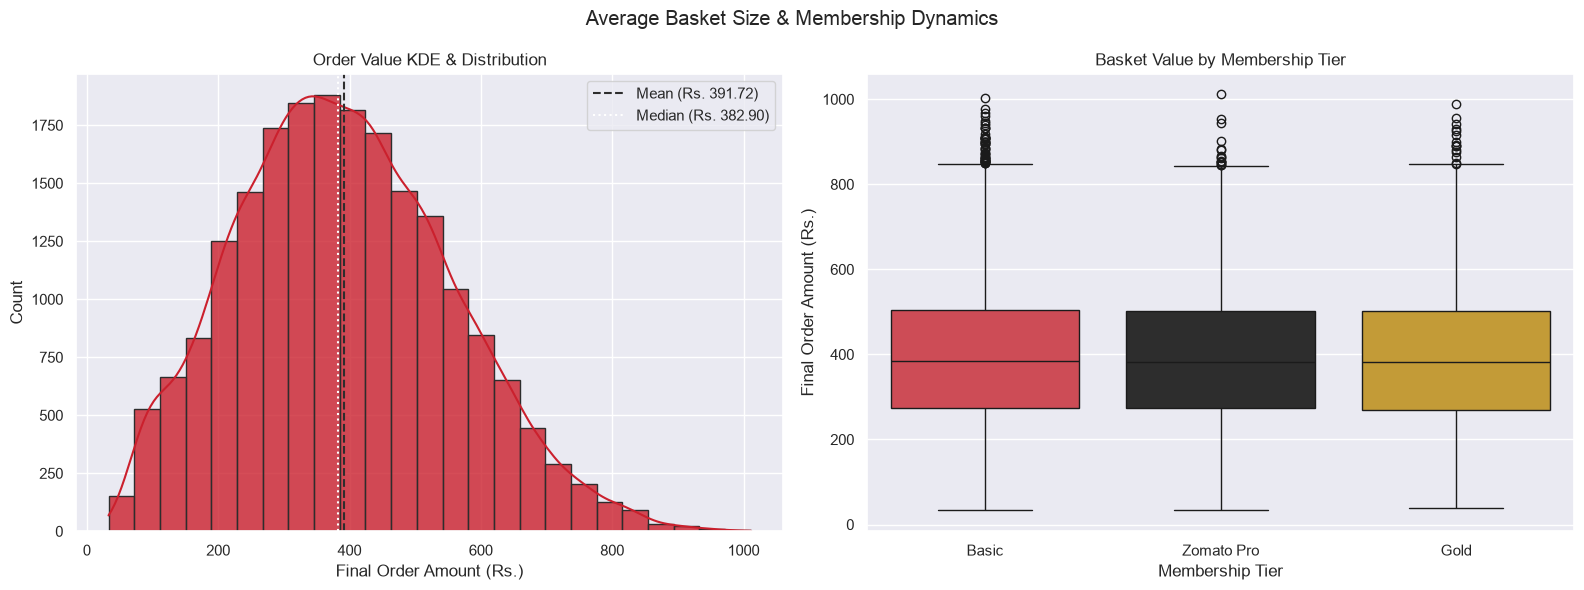

In [78]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Average Basket Size & Membership Dynamics")

sns.histplot(
    data=orders_cm,
    x='FinalAmount',
    kde=True,
    bins=25,
    color=ZOMATO_DARK_RED,
    edgecolor=CHARCOAL,
    alpha=0.8,
    ax=axes[0],
)
mean_aov = orders_cm['FinalAmount'].mean()
median_aov = orders_cm['FinalAmount'].median()
axes[0].axvline(mean_aov, color=CHARCOAL, linestyle='--', label=f'Mean (Rs. {mean_aov:,.2f})')
axes[0].axvline(median_aov, color='white', linestyle=':', label=f'Median (Rs. {median_aov:,.2f})')
axes[0].set_title('Order Value KDE & Distribution')
axes[0].set_xlabel('Final Order Amount (Rs.)')
axes[0].legend(loc='upper right')

sns.boxplot(
    data=orders_cm,
    x='Membership',
    y='FinalAmount',
    order=tier_order,
    palette=[ZOMATO_RED, CHARCOAL, 'goldenrod'],
    ax=axes[1],
)
axes[1].set_title('Basket Value by Membership Tier')
axes[1].set_xlabel('Membership Tier')
axes[1].set_ylabel('Final Order Amount (Rs.)')

plt.tight_layout()
plt.show()


Output : 
- The bell-curve peaks around Rs. 300-400 and IQRs are nearly identical across all four membership tiers (270-500 range)so membership tier doesn't change how much someone spends per order. 
- Whatever value Basic, Gold, Pro or Standard memberships add, it's affecting order frequency and not basket size.

### Repeating vs One-Time Customers

In [79]:

orders_fc = orders.copy()
# 1. Calculate Total Unique Customers & Total Orders
total_unique_customers = orders_fc['CustomerID'].nunique()
total_orders_count = len(orders_fc)
# 2. Group by CustomerID and count orders
customer_freq = orders_fc.groupby('CustomerID').size().reset_index()

# 3. Explicitly rename columns to avoid key errors
customer_freq.columns = ['CustomerID', 'TotalOrders']

In [80]:
# 2+ orders counts as a repeat customer, 1 order counts as one-time
customer_freq['CustomerSegment'] = np.where(
    customer_freq['TotalOrders'] >= 2, 'Repeat', 'One-Time')


In [81]:
segment_summary = (
    customer_freq['CustomerSegment']
    .value_counts()
    .reset_index()
)
segment_summary.columns = ['CustomerSegment', 'UserCount']


In [82]:
# Calculate Exact Percentage
segment_summary['Percentage'] = (
    segment_summary['UserCount'] / total_unique_customers
) * 100

# Extract Segment Metrics
repeat_users = segment_summary.loc[
    segment_summary['CustomerSegment'] == 'Repeat', 'UserCount'
].values[0]

onetime_users = segment_summary.loc[
    segment_summary['CustomerSegment'] == 'One-Time', 'UserCount'
].values[0]

repeat_rate_pct = (repeat_users / total_unique_customers) * 100
avg_purchase_freq = total_orders_count / total_unique_customers

In [83]:
print("Customer retention metrics summary")
print(f"Total Unique Customers : {total_unique_customers:,}")
print(f"One-Time Customers     : {onetime_users:,} ({(onetime_users/total_unique_customers)*100:.2f}%)")
print(f"Repeat Customers (2+)  : {repeat_users:,} ({repeat_rate_pct:.2f}%)")
print(f"Avg Purchase Frequency : {avg_purchase_freq:.2f} orders/customer")
print("\nSegment Summary Matrix:")
print(segment_summary.to_string(index=False))

Customer retention metrics summary
Total Unique Customers : 9,827
One-Time Customers     : 3,715 (37.80%)
Repeat Customers (2+)  : 6,112 (62.20%)
Avg Purchase Frequency : 2.08 orders/customer

Segment Summary Matrix:
CustomerSegment  UserCount  Percentage
         Repeat       6112   62.195991
       One-Time       3715   37.804009


#### Visualization of Customer Retention Summary

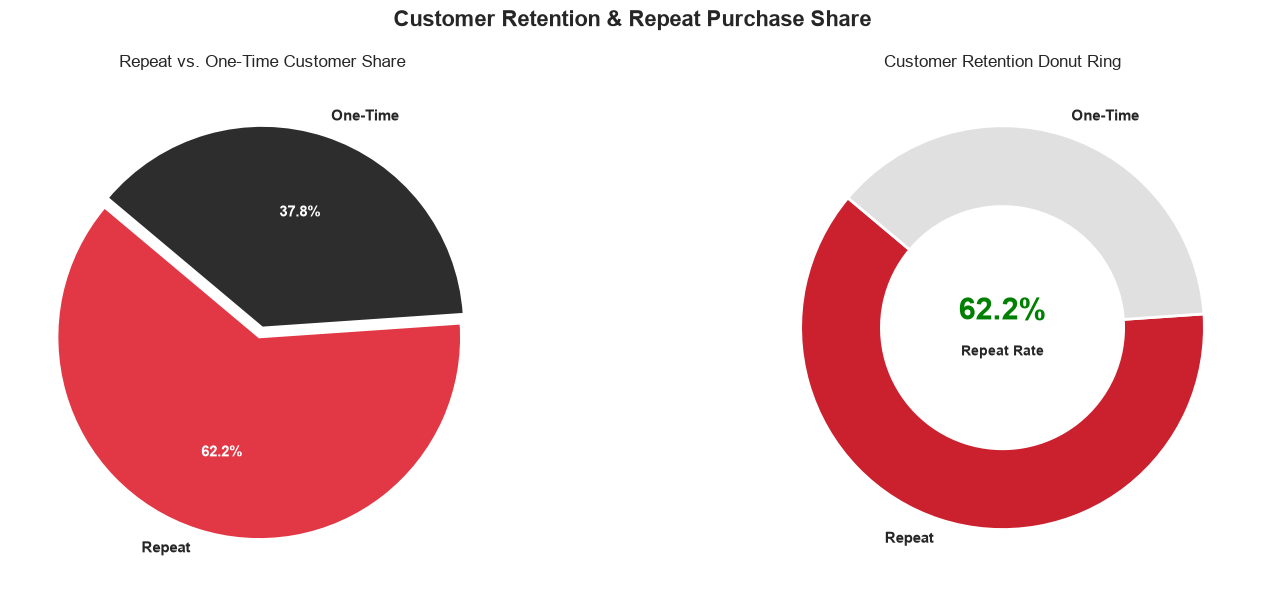

In [84]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Customer Retention & Repeat Purchase Share', fontsize=16, fontweight='bold')

# 1. Pie Chart
wedges, texts, autotexts = axes[0].pie(
    segment_summary['UserCount'],
    labels=segment_summary['CustomerSegment'],
    autopct='%1.1f%%',
    startangle=140,
    colors=[ZOMATO_RED, CHARCOAL],
    explode=(0.05, 0),
    wedgeprops={'edgecolor': 'white', 'lw': 1.5},
    textprops={'fontweight': 'bold'},
)
plt.setp(autotexts, color='white', fontsize=11)
axes[0].set_title('Repeat vs. One-Time Customer Share')

# 2. Donut Chart
axes[1].pie(
    segment_summary['UserCount'],
    labels=segment_summary['CustomerSegment'],
    startangle=140,
    colors=[ZOMATO_DARK_RED, NEUTRAL_GREY],
    wedgeprops={'width': 0.4, 'edgecolor': 'white', 'lw': 2},
    textprops={'fontweight': 'bold'},
)

# Central Callout
axes[1].text(0, 0.08, f'{repeat_rate_pct:.1f}%', ha='center', va='center', fontsize=22, fontweight='bold', color='green')
axes[1].text(0, -0.12, 'Repeat Rate', ha='center', va='center', fontsize=10, fontweight='bold')

axes[1].set_title('Customer Retention Donut Ring')

plt.tight_layout()
plt.show()

Output : 
- Based on summary and visualization, 62.2% of the 9,827 unique customers (6,112 of them) are repeat customers with 2+ orders and the remaining 37.8% (3,715) have only ordered once. 
- Average frequency across the whole base is 2.08 orders/customer which is worth keeping an eye on for the churn model, since a large chunk of the base is already a single order away from looking inactive.

### Fastest & Top Rated Delivery Partners

In [85]:
orders_dp = orders.copy()
dp_df = delivery_partners.copy()

# guard against whitespace/casing differences in column names between the two tables
dp_df.columns = dp_df.columns.str.strip()

order_partner_col = [c for c in orders_dp.columns if 'partner' in c.lower() or 'driver' in c.lower()]
dp_partner_col = [c for c in dp_df.columns if 'partner' in c.lower() or 'driver' in c.lower()]

order_key = order_partner_col[0] if order_partner_col else 'DeliveryPartnerID'
dp_key = dp_partner_col[0] if dp_partner_col else 'DeliveryPartnerID'

rating_candidates = [c for c in dp_df.columns if 'rating' in c.lower()]
rating_col_name = rating_candidates[0] if rating_candidates else 'Rating'
dp_df.rename(columns={rating_col_name: 'Rating'}, inplace=True)

orders_dp = orders_dp.merge(
    dp_df,
    left_on=order_key,
    right_on=dp_key,
    how='left',
    suffixes=('', '_dp')
)
orders_dp = orders_dp.dropna(subset=['DeliveryTimeMinutes', 'Rating'])

group_cols = [order_key]
if 'Name' in orders_dp.columns:
    group_cols.append('Name')
if 'VehicleType' in orders_dp.columns:
    group_cols.append('VehicleType')

partner_perf = (
    orders_dp.groupby(group_cols)
    .agg(
        AvgDeliveryTime=('DeliveryTimeMinutes', 'mean'),
        ProfileAvgTime=('AverageDeliveryTime', 'first'),
        PartnerRating=('Rating', 'mean'),
        TotalOrdersCompleted=('DeliveryTimeMinutes', 'count')
    )
    .reset_index()
)

# need a minimum sample size per partner so a single lucky/unlucky order doesn't rank them
min_orders = 5 if (partner_perf['TotalOrdersCompleted'] >= 5).any() else 1

fastest_drivers = partner_perf[
    partner_perf['TotalOrdersCompleted'] >= min_orders
].sort_values(by='AvgDeliveryTime', ascending=True)

top_rated_drivers = partner_perf[
    partner_perf['TotalOrdersCompleted'] >= min_orders
].sort_values(by=['PartnerRating', 'AvgDeliveryTime'], ascending=[False, True])

display_cols = [c for c in [order_key, 'Name', 'VehicleType', 'AvgDeliveryTime', 'PartnerRating', 'TotalOrdersCompleted'] if c in partner_perf.columns]

print("TOP 5 FASTEST DELIVERY PARTNERS: ")
print(fastest_drivers[display_cols].head(5).to_string(index=False))

print("\nTOP 5 HIGHEST RATED DELIVERY PARTNERS: ")
print(top_rated_drivers[display_cols].head(5).to_string(index=False))

print("\nDELIVERY PARTNER LOGISTICS SUMMARY (TOP 10): ")
print(partner_perf.head(10).to_string(index=False))


TOP 5 FASTEST DELIVERY PARTNERS: 
 DeliveryPartnerID             Name VehicleType  AvgDeliveryTime  PartnerRating  TotalOrdersCompleted
              1423     Ekaraj Tella        Bike             21.5            4.3                     6
              1061 Benjamin Chhabra     Scooter             22.5            4.2                     6
              1607        Jagat Sem        Bike        22.857143            4.5                     7
               233    Falguni Borah        Bike        23.916667            4.3                    12
              1679      Jasmit Dara     Scooter             24.0            3.9                     6

TOP 5 HIGHEST RATED DELIVERY PARTNERS: 
 DeliveryPartnerID             Name VehicleType  AvgDeliveryTime  PartnerRating  TotalOrdersCompleted
                56 Bhanumati Mangal     Scooter           29.375            5.0                     8
              1510      Krishna Ray        Bike             30.4            5.0                    10
       

#### Visualization of Fastest & Top Delivery Partners

/var/folders/14/vwm12jsj6k54dqpcrph9h29w0000gp/T/ipykernel_91746/1734180790.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


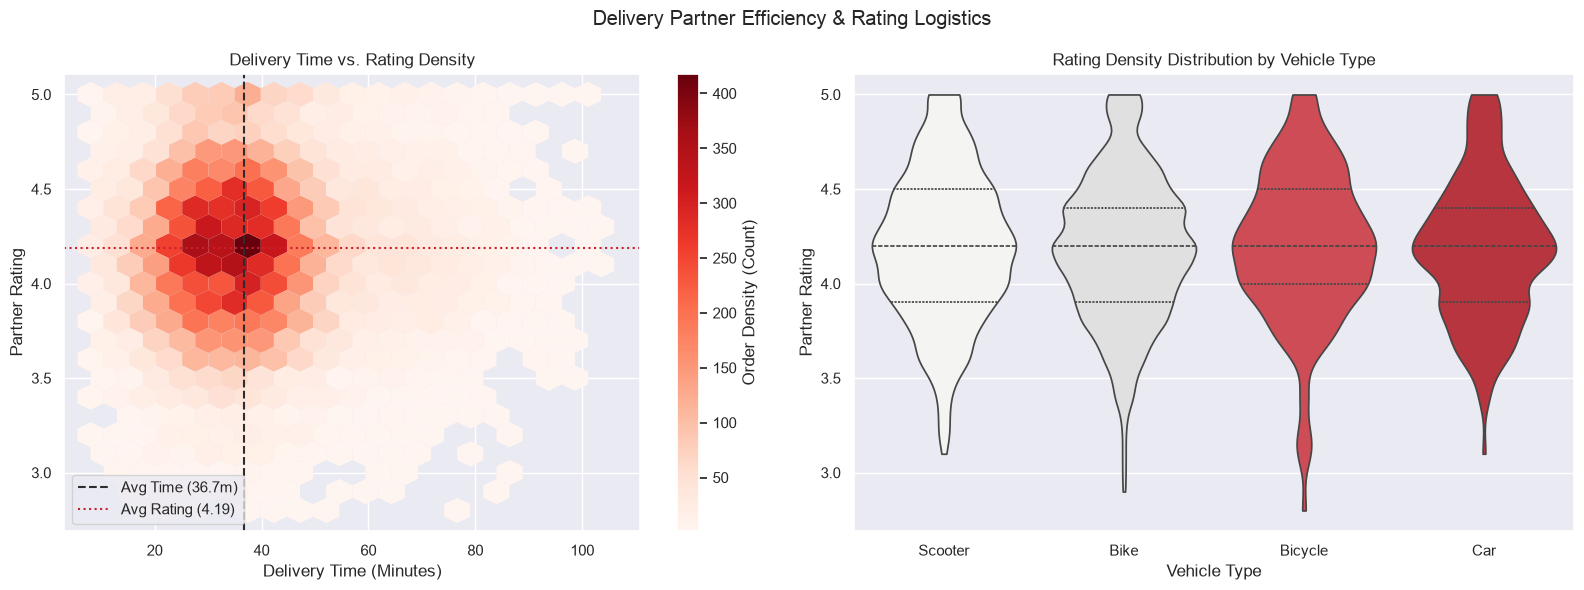

In [86]:
# Cap delivery time outliers for visual clarity on the x-axis (< 120 mins)
orders_dp_clean = orders_dp[orders_dp['DeliveryTimeMinutes'] <= 120].copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Delivery Partner Efficiency & Rating Logistics')

hb = axes[0].hexbin(
    orders_dp_clean['DeliveryTimeMinutes'],
    orders_dp_clean['Rating'],
    gridsize=20,
    cmap='Reds',
    mincnt=1,
    edgecolors='none',
)
cb = fig.colorbar(hb, ax=axes[0])
cb.set_label('Order Density (Count)')

mean_dt = orders_dp_clean['DeliveryTimeMinutes'].mean()
mean_rating = orders_dp_clean['Rating'].mean()
axes[0].axvline(mean_dt, color=CHARCOAL, linestyle='--', label=f'Avg Time ({mean_dt:.1f}m)')
axes[0].axhline(mean_rating, color=ZOMATO_DARK_RED, linestyle=':', label=f'Avg Rating ({mean_rating:.2f})')
axes[0].set_title('Delivery Time vs. Rating Density')
axes[0].set_xlabel('Delivery Time (Minutes)')
axes[0].set_ylabel('Partner Rating')
axes[0].legend(loc='lower left')

sns.violinplot(
    data=orders_dp,
    x='VehicleType',
    y='Rating',
    palette=[NEUTRAL_BOX, NEUTRAL_GREY, ZOMATO_RED, ZOMATO_DARK_RED],
    inner='quartile',
    cut=0,
    ax=axes[1],
)
axes[1].set_title('Rating Density Distribution by Vehicle Type')
axes[1].set_xlabel('Vehicle Type')
axes[1].set_ylabel('Partner Rating')

plt.tight_layout()
plt.show()


Output:
- Delivery Time vs. Rating Density: Orders density peaks at 30-40min of delivery time with rating between 4.0-4.5 and hitting maximum density orders > 250 and avg. delivery time 36.7min and avg. rating being 4.19.
- Ratings are pretty stable till 50 min delivery time but sharply drops at 60min.
- Rating Density Distribution by Vehicle Type: Ratings remain identical across all vehicle types. 
- Bicycle shows a slightly longer low-rating tail extending down to 2.8, but overall vehicle choice has no significant impact on delivery partner ratings.

### Order Status & Cancellation Analysis

In [87]:
orders_os = orders.copy()

# Order status breakdown (computed live below - not hardcoded, since it
# needs to reflect whatever's in the cleaned data at run time)
status_counts = (
    orders_os['OrderStatus']
    .value_counts()
    .reset_index()
)
status_counts.columns = ['OrderStatus', 'OrderVolume']
status_counts['Percentage'] = (
    status_counts['OrderVolume'] / status_counts['OrderVolume'].sum()
) * 100

total_orders_os = len(orders_os)
completed_orders = status_counts.loc[
    status_counts['OrderStatus'] ==
    'Delivered', 'OrderVolume'
].values[0] if 'Delivered' in status_counts['OrderStatus'].values else 0

non_completed_orders = total_orders_os - completed_orders
completion_rate = (completed_orders / total_orders_os) * 100
issue_rate = (non_completed_orders / total_orders_os) * 100

print("Order status & fulfillment summary:")
print(f"Total Orders Evaluated : {total_orders_os:,}")
print(f"Successfully Delivered : {completed_orders:,} ({completion_rate:.2f}%)")
print(f"Orders with Issues/Cancel: {non_completed_orders:,} ({issue_rate:.2f}%)")
print("\nDetailed Status Breakdown:")
print(status_counts.to_string(index=False))

# Merge with feedback to see if cancelled/late orders also get worse sentiment
if 'OrderID' in orders_os.columns and 'OrderID' in customer_feedback.columns:
    feedback_q7 = orders_os.merge(customer_feedback, on='OrderID', how='inner')
    negative_feedback = feedback_q7[
        (feedback_q7['OrderStatus'] != 'Delivered') |
        (feedback_q7['Sentiment'].str.lower() == 'negative')
    ]
    print(f"\nMerged Feedback Records for Defect Analysis: {len(negative_feedback):,}")


Order status & fulfillment summary:
Total Orders Evaluated : 20,475
Successfully Delivered : 11,390 (55.63%)
Orders with Issues/Cancel: 9,085 (44.37%)

Detailed Status Breakdown:
       OrderStatus  OrderVolume  Percentage
         Delivered        11390   55.628816
         Cancelled         4569   22.315018
Food Not Delivered         2362   11.536020
    Delivered Late         2154   10.520147

Merged Feedback Records for Defect Analysis: 6,663


#### Visualization of Order Status

/var/folders/14/vwm12jsj6k54dqpcrph9h29w0000gp/T/ipykernel_91746/98136069.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


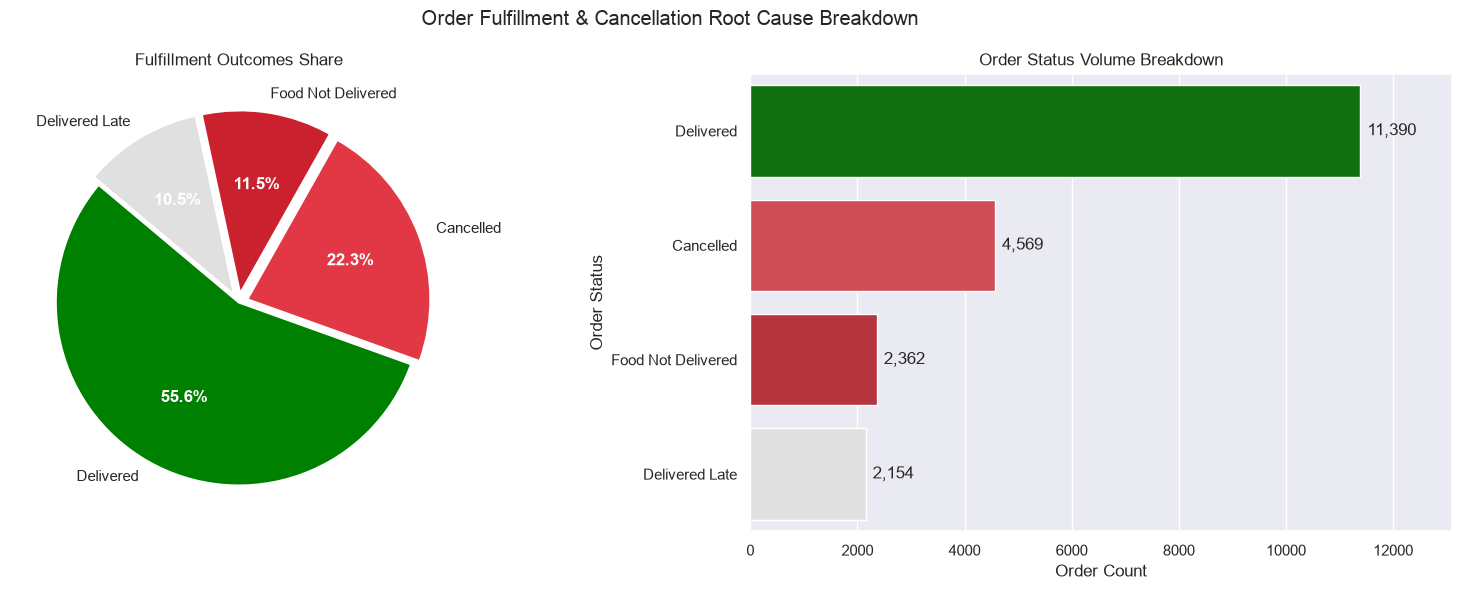

In [88]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Order Fulfillment & Cancellation Root Cause Breakdown')

status_colors = ['green', ZOMATO_RED, ZOMATO_DARK_RED, NEUTRAL_GREY]
explode = [0 if status == 'Delivered' else 0.05 for status in status_counts['OrderStatus']]

# 1. Fulfillment Outcomes Pie Chart
wedges, texts, autotexts = axes[0].pie(
    status_counts['OrderVolume'],
    labels=status_counts['OrderStatus'],
    autopct='%1.1f%%',
    startangle=140,
    colors=status_colors,
    explode=explode,
    wedgeprops={'edgecolor': 'white', 'lw': 1.5},
)
plt.setp(autotexts, color='white', fontweight='bold')
axes[0].set_title('Fulfillment Outcomes Share')

# 2. Order Status Volume Bar Chart
sns.countplot(
    data=orders_os,
    y='OrderStatus',
    order=status_counts['OrderStatus'],
    palette=status_colors,
    ax=axes[1],
)

# Label all bar containers
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='{:,.0f}', padding=5)
    
axes[1].set_xlim(0, status_counts['OrderVolume'].max() * 1.15)
axes[1].set_title('Order Status Volume Breakdown')
axes[1].set_xlabel('Order Count')
axes[1].set_ylabel('Order Status')

plt.tight_layout()
plt.show()

Output : 
- Cancellations are 22.3% of all orders regardless of status breakdown. T
- The root-cause check below (rain, traffic, peak hours) is where it gets interesting because none of those factors actually move the cancellation rate much.

=== ORDER OUTCOME (%) BY RAIN (0=No Rain, 1=Rain) ===
OrderStatus  Cancelled  Delivered  Delivered Late  Food Not Delivered
RainImpact                                                           
0                 22.1       56.0            10.5                11.4
1                 24.5       52.4            10.3                12.7

=== ORDER OUTCOME (%) BY TRAFFIC SCORE (1=Low ... 4=Severe) ===
OrderStatus   Cancelled  Delivered  Delivered Late  Food Not Delivered
TrafficScore                                                          
1                  22.1       55.3            10.8                11.8
2                  22.7       55.7            10.3                11.3
3                  22.2       55.5            10.8                11.5
4                  20.2       56.4            10.8                12.6

=== ORDER OUTCOME (%) BY PEAK HOUR (0=Off-Peak, 1=Peak) ===
OrderStatus  Cancelled  Delivered  Delivered Late  Food Not Delivered
PeakHour                                    

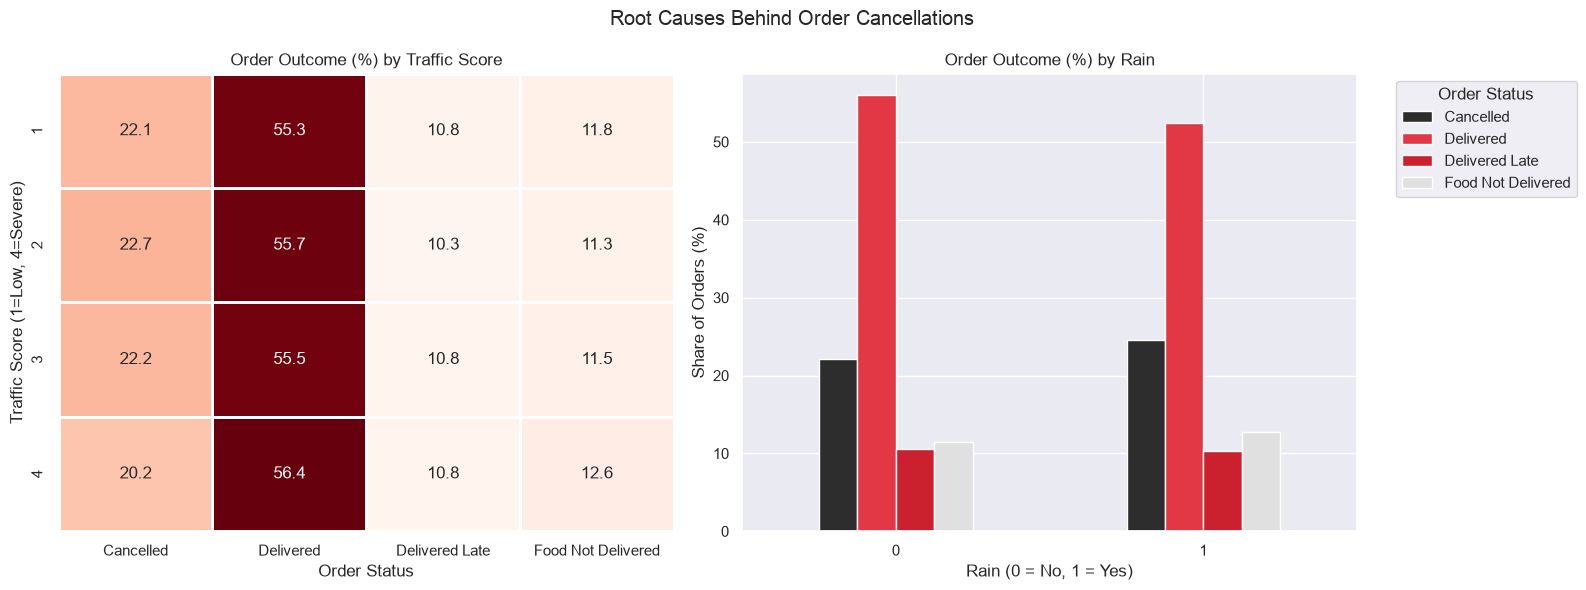

In [89]:
# Cancellation root causes: rain, traffic congestion, and peak-hour load
rain_ct = pd.crosstab(df_feat['RainImpact'], df_feat['OrderStatus'], normalize='index') * 100
traffic_ct = pd.crosstab(df_feat['TrafficScore'], df_feat['OrderStatus'], normalize='index') * 100
peak_ct = pd.crosstab(df_feat['PeakHour'], df_feat['OrderStatus'], normalize='index') * 100

print("=== ORDER OUTCOME (%) BY RAIN (0=No Rain, 1=Rain) ===")
print(rain_ct.round(1))
print("\n=== ORDER OUTCOME (%) BY TRAFFIC SCORE (1=Low ... 4=Severe) ===")
print(traffic_ct.round(1))
print("\n=== ORDER OUTCOME (%) BY PEAK HOUR (0=Off-Peak, 1=Peak) ===")
print(peak_ct.round(1))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Root Causes Behind Order Cancellations")

sns.heatmap(
    traffic_ct,
    annot=True,
    fmt=".1f",
    cmap="Reds",
    cbar=False,
    linewidths=1,
    linecolor="white",
    ax=axes[0],
)
axes[0].set_title("Order Outcome (%) by Traffic Score")
axes[0].set_xlabel("Order Status")
axes[0].set_ylabel("Traffic Score (1=Low, 4=Severe)")

rain_ct.plot(
    kind="bar",
    color=[CHARCOAL, ZOMATO_RED, ZOMATO_DARK_RED, NEUTRAL_GREY],
    edgecolor="white",
    ax=axes[1],
)
axes[1].set_title("Order Outcome (%) by Rain")
axes[1].set_xlabel("Rain (0 = No, 1 = Yes)")
axes[1].set_ylabel("Share of Orders (%)")
axes[1].tick_params(axis="x", rotation=0)
axes[1].legend(title="Order Status", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()


### Delivery Time vs. Traffic & Weather Conditions

/var/folders/14/vwm12jsj6k54dqpcrph9h29w0000gp/T/ipykernel_91746/3259061713.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/14/vwm12jsj6k54dqpcrph9h29w0000gp/T/ipykernel_91746/3259061713.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[1].set_xticklabels(['No Rain', 'Rain'])


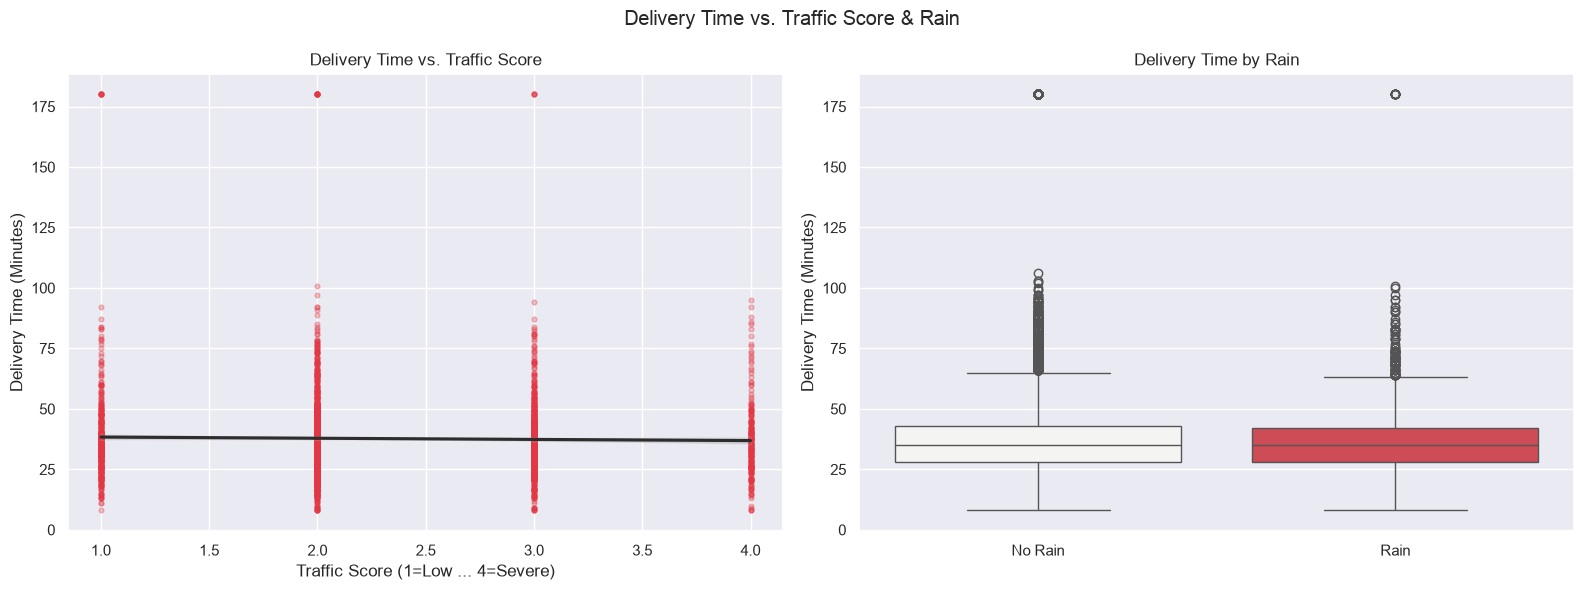

Correlation (TrafficScore, DeliveryTimeMinutes): -0.0013
RainImpact
0    37.8
1    37.3
Name: DeliveryTimeMinutes, dtype: float64


In [90]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Delivery Time vs. Traffic Score & Rain")

sample_df = df_feat.sample(n=min(3000, len(df_feat)), random_state=42)

sns.regplot(
    data=sample_df,
    x='TrafficScore',
    y='DeliveryTimeMinutes',
    scatter_kws={'alpha': 0.3, 'color': ZOMATO_RED, 's': 12},
    line_kws={'color': CHARCOAL},
    ax=axes[0],
)
axes[0].set_title('Delivery Time vs. Traffic Score')
axes[0].set_xlabel('Traffic Score (1=Low ... 4=Severe)')
axes[0].set_ylabel('Delivery Time (Minutes)')

sns.boxplot(
    data=df_feat,
    x='RainImpact',
    y='DeliveryTimeMinutes',
    palette=[NEUTRAL_BOX, ZOMATO_RED],
    ax=axes[1],
)
axes[1].set_xticklabels(['No Rain', 'Rain'])
axes[1].set_title('Delivery Time by Rain')
axes[1].set_xlabel('')
axes[1].set_ylabel('Delivery Time (Minutes)')

plt.tight_layout()
plt.show()

print('Correlation (TrafficScore, DeliveryTimeMinutes):', round(df_feat[['TrafficScore','DeliveryTimeMinutes']].corr().iloc[0,1], 4))
print(df_feat.groupby('RainImpact')['DeliveryTimeMinutes'].mean().round(1))


Output : Correlation between TrafficScore and delivery time is basically zero (-0.001), and mean delivery time barely moves between rain (37.3m) and no rain (37.8m). In this dataset, traffic/weather don't meaningfully explain delay.

### Distribution Shape: Delivery Time & Food Cost (KDE)

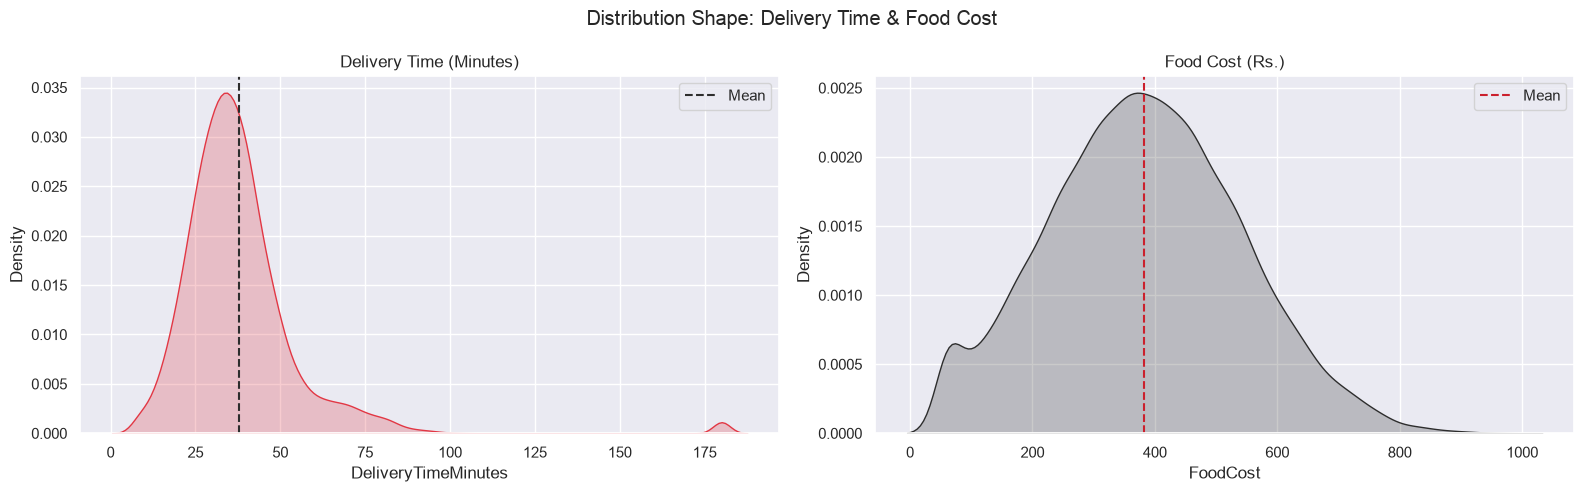

In [91]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Distribution Shape: Delivery Time & Food Cost")

sns.kdeplot(df_feat['DeliveryTimeMinutes'], fill=True, color=ZOMATO_RED, ax=axes[0])
axes[0].axvline(df_feat['DeliveryTimeMinutes'].mean(), color=CHARCOAL, linestyle='--', label='Mean')
axes[0].set_title('Delivery Time (Minutes)')
axes[0].legend()

sns.kdeplot(df_feat['FoodCost'], fill=True, color=CHARCOAL, ax=axes[1])
axes[1].axvline(df_feat['FoodCost'].mean(), color=ZOMATO_DARK_RED, linestyle='--', label='Mean')
axes[1].set_title('Food Cost (Rs.)')
axes[1].legend()

plt.tight_layout()
plt.show()


Output : Both distributions are right-skewed with a long tail. It is expected for delivery time (a few badly delayed orders), less obvious for food cost probably a handful of large multi-item orders pulling the tail out.

### Feature Relationships: Correlation Heatmap

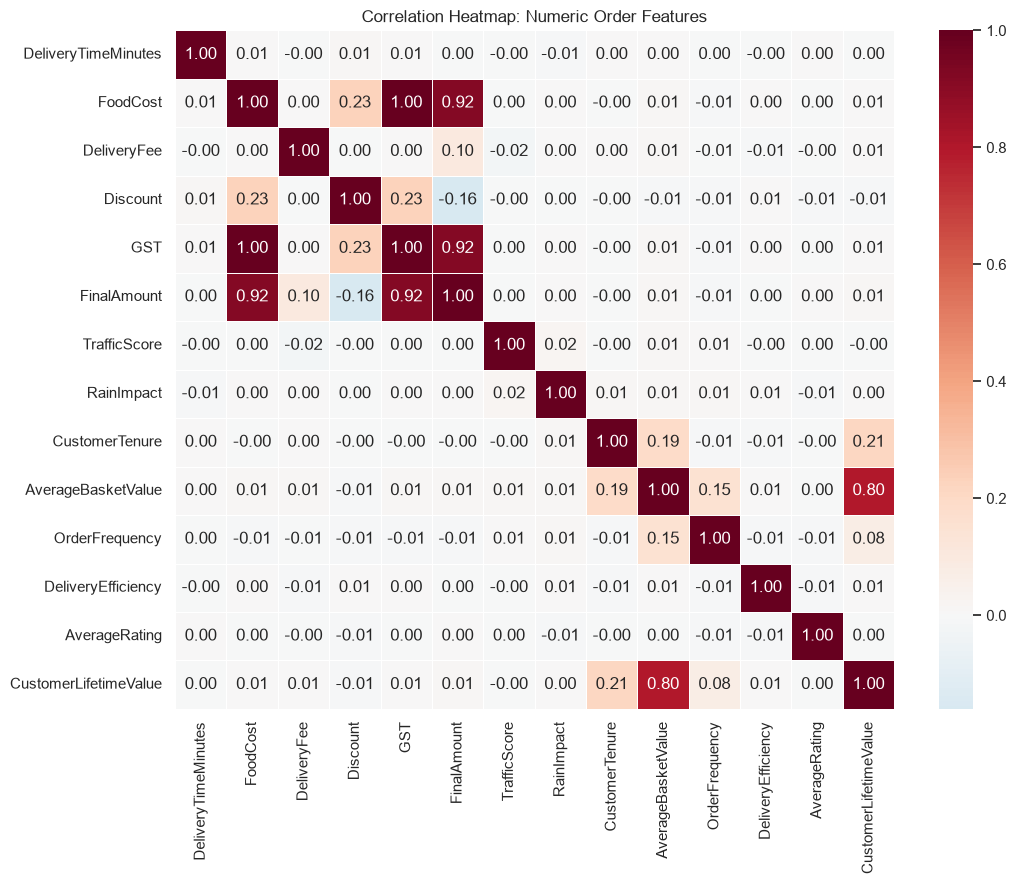

In [92]:
num_cols = [
    'DeliveryTimeMinutes', 'FoodCost', 'DeliveryFee', 'Discount', 'GST', 'FinalAmount',
    'TrafficScore', 'RainImpact', 'CustomerTenure', 'AverageBasketValue',
    'OrderFrequency', 'DeliveryEfficiency', 'AverageRating', 'CustomerLifetimeValue',
]
corr = df_feat[num_cols].corr()

plt.figure(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, linewidths=0.5)
plt.title('Correlation Heatmap: Numeric Order Features')
plt.tight_layout()
plt.show()


Output : 
- FoodCost and GST are perfectly correlated (1.0) since GST is calculated as a fixed percentage of FoodCost - not a real finding, just confirms how the field was derived. 
- Interestingly, order frequency (0.08) has almost no bearing on lifetime value here, meaning getting customers to place bigger orders per visit drives far more long-term value than just getting them to order more often.
- Delivery time, traffic scores, rain impact, and delivery efficiency show virtually zero correlation with order totals or customer metrics (all hovering right around 0.00). Customers seem to spend and stick around roughly the same amount regardless of traffic, weather, or delivery speed.

### Feature Relationships: Pairplot

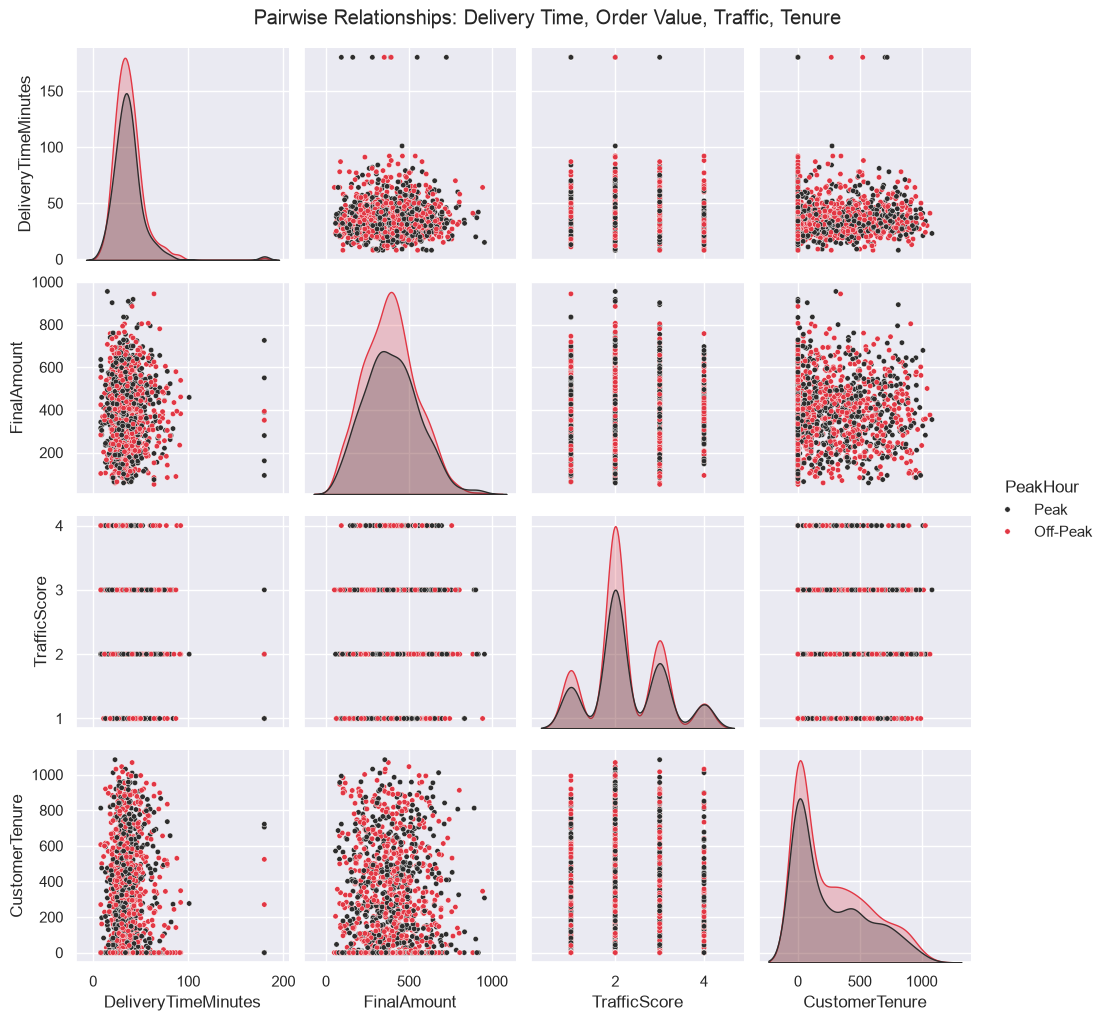

In [93]:
pairplot_cols = ['DeliveryTimeMinutes', 'FinalAmount', 'TrafficScore', 'CustomerTenure']
pairplot_sample = df_feat[pairplot_cols + ['PeakHour']].sample(n=min(1500, len(df_feat)), random_state=42)
pairplot_sample['PeakHour'] = pairplot_sample['PeakHour'].map({0: 'Off-Peak', 1: 'Peak'})

g = sns.pairplot(
    pairplot_sample,
    vars=pairplot_cols,
    hue='PeakHour',
    palette=[CHARCOAL, ZOMATO_RED],
    plot_kws={'alpha': 1, 's': 15},
    diag_kind='kde',
)
g.figure.suptitle('Pairwise Relationships: Delivery Time, Order Value, Traffic, Tenure', y=1.02)
plt.show()


Output : 
- Delivery times mostly group between 20 and 60 minutes, while order amounts hover around 200 to 600. 
- There is no strong linear trend between the two, as high order values occur across both quick and delayed deliveries. 
- While peak hours show slightly higher delivery times on average, order values stay evenly distributed regardless of whether it is peak or off-peak hours. 
- Meanwhile, traffic scores concentrate around levels 2 and 3 with minimal impact on total order amounts. 
- Lastly, customer tenure is mostly skewed toward newer customers under 300 days, who exhibit spending and delivery time patterns similar to longer-tenured customers.

### Rating Distribution by Cuisine

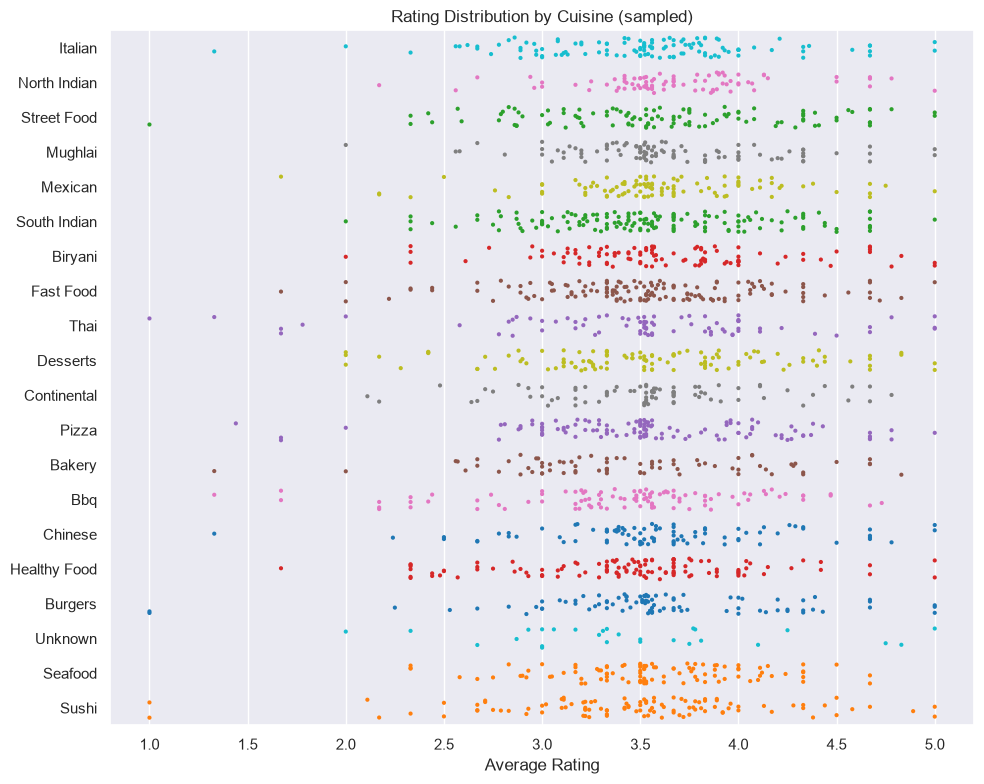

In [94]:
df_feat_cuisine = df_feat.copy()
df_feat_cuisine['RestaurantID'] = df_feat_cuisine['RestaurantID'].astype(str)
rest_cuisine = restaurants[['RestaurantID', 'Cuisine']].copy()
rest_cuisine['RestaurantID'] = rest_cuisine['RestaurantID'].astype(str)
df_feat_cuisine = df_feat_cuisine.merge(rest_cuisine, on='RestaurantID', how='left')

cuisine_order = (
    df_feat_cuisine.groupby('Cuisine')['AverageRating'].mean().sort_values(ascending=False).index
)
strip_sample = df_feat_cuisine.sample(n=min(2000, len(df_feat_cuisine)), random_state=42)

plt.figure(figsize=(10, 8))
sns.stripplot(
    data=strip_sample,
    x='AverageRating',
    y='Cuisine',
    order=cuisine_order,
    hue= 'Cuisine',
    palette='tab10',
    alpha=1,
    jitter=0.3,
    size=3,
)
plt.title('Rating Distribution by Cuisine (sampled)')
plt.xlabel('Average Rating')
plt.ylabel('')
plt.tight_layout()
plt.show()


Output : 
- Italian (3.63) and North Indian (3.60) edge out the pack.
- Sushi and Seafood sit lowest (3.43-3.46). It's a narrow spread overall - cuisine choice alone doesn't explain much of the rating variance.

### Payment Method Share

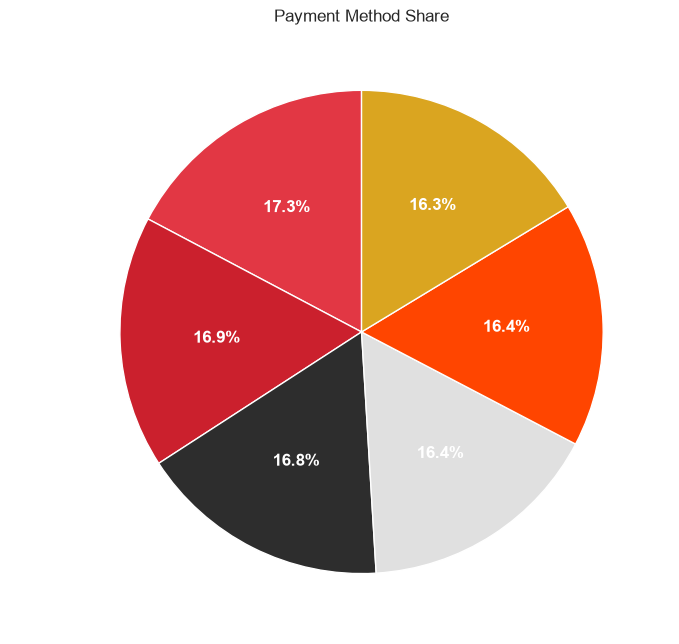

PaymentMethod
Debit Card          17.3
Net Banking         16.9
Cash On Delivery    16.8
Credit Card         16.4
Wallet              16.4
Upi                 16.3
Name: proportion, dtype: float64


In [95]:
payment_counts = orders['PaymentMethod'].value_counts()

plt.figure(figsize=(7, 7))
plt.pie(
    payment_counts.values,
    labels=payment_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=sns.color_palette([ZOMATO_RED, ZOMATO_DARK_RED, CHARCOAL, NEUTRAL_GREY, 'orangered', 'goldenrod']),
    textprops={'color': 'white', 'weight': 'bold'}

)
plt.title('Payment Method Share')
plt.tight_layout()
plt.show()

print(orders['PaymentMethod'].value_counts(normalize=True).mul(100).round(1))


Output : 
- Payment methods are almost perfectly evenly split (16.3-17.3% each across all six options) - no dominant method. Not much of a lever here for the payments/checkout experience.

### Customer Lifetime Value Distribution by City & Cuisine

/var/folders/14/vwm12jsj6k54dqpcrph9h29w0000gp/T/ipykernel_91746/117710531.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


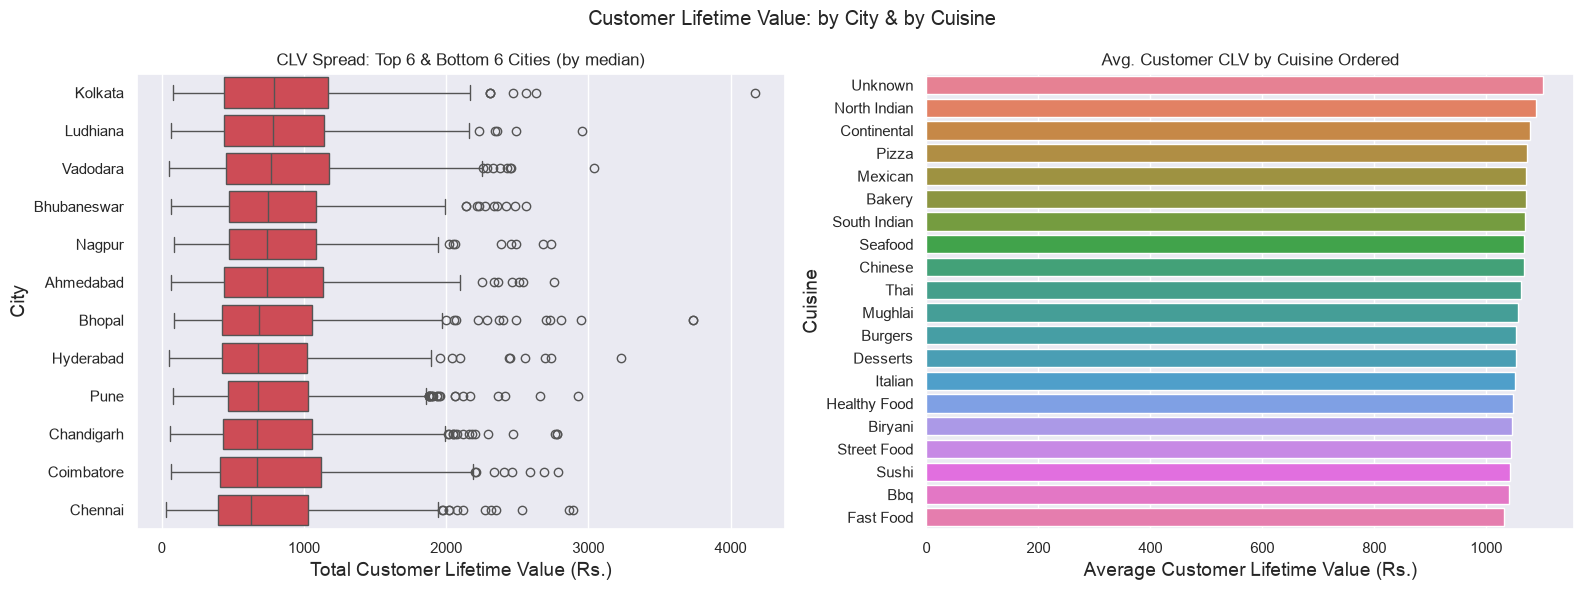

Overall CLV summary:
count    9827.00
mean      816.16
std       504.25
min        33.00
25%       429.62
50%       710.85
75%      1087.22
max      4172.75
Name: TotalCLV, dtype: float64


In [96]:
# Total CLV per customer (sum of all their orders)
orders_clv = orders.copy()
orders_clv['CustomerID'] = orders_clv['CustomerID'].astype(str)
customers_clv = customers.copy()
customers_clv['CustomerID'] = customers_clv['CustomerID'].astype(str)

customer_total_clv = orders_clv.groupby('CustomerID')['FinalAmount'].sum().reset_index(name='TotalCLV')
clv_by_city = customer_total_clv.merge(customers_clv[['CustomerID', 'City']], on='CustomerID', how='left')

top_bottom_cities = (
    clv_by_city.groupby('City')['TotalCLV'].median().sort_values(ascending=False)
)
top_bottom_cities = pd.concat([top_bottom_cities.head(6), top_bottom_cities.tail(6)])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Customer Lifetime Value: by City & by Cuisine")

sns.boxplot(
    data=clv_by_city[clv_by_city['City'].isin(top_bottom_cities.index)],
    x='TotalCLV',
    y='City',
    order=top_bottom_cities.index,
    color=ZOMATO_RED,
    ax=axes[0],
)
axes[0].set_title('CLV Spread: Top 6 & Bottom 6 Cities (by median)')
axes[0].set_xlabel('Total Customer Lifetime Value (Rs.)', fontsize=14)
axes[0].set_ylabel('City', fontsize=14)

orders_clv['RestaurantID'] = orders_clv['RestaurantID'].astype(str)
rest_cuisine2 = restaurants[['RestaurantID', 'Cuisine']].copy()
rest_cuisine2['RestaurantID'] = rest_cuisine2['RestaurantID'].astype(str)
orders_cuisine_clv = orders_clv.merge(rest_cuisine2, on='RestaurantID', how='left').merge(
    customer_total_clv, on='CustomerID', how='left'
)
cuisine_clv = orders_cuisine_clv.groupby('Cuisine')['TotalCLV'].mean().sort_values(ascending=False)

sns.barplot(
    x=cuisine_clv.values, 
    y=cuisine_clv.index, 
    palette='husl', 
    ax=axes[1])
axes[1].set_title('Avg. Customer CLV by Cuisine Ordered')
axes[1].set_xlabel('Average Customer Lifetime Value (Rs.)', fontsize=14)
axes[1].set_ylabel('Cuisine', fontsize=14)
plt.tight_layout()
plt.show()

print('Overall CLV summary:')
print(customer_total_clv['TotalCLV'].describe().round(2))


Output : 
- Customer Lifetime value doesn't change a whole lot from city to city. Vadodara sits near the top with a median around 873, while Chennai lands on the lower end around 772.
- Where you actually see a difference is in what people eat. People who order North Indian, Continental, or Pizza bring in a higher average value (around 1,070 to 1,090) compared to those getting Sushi, BBQ, or Fast Food (around 1,030 to 1,040). It makes sense to focus retention campaigns on those higher-spending cuisine groups.


### Revenue by City & Cuisine Mix per City

/var/folders/14/vwm12jsj6k54dqpcrph9h29w0000gp/T/ipykernel_91746/2424983629.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


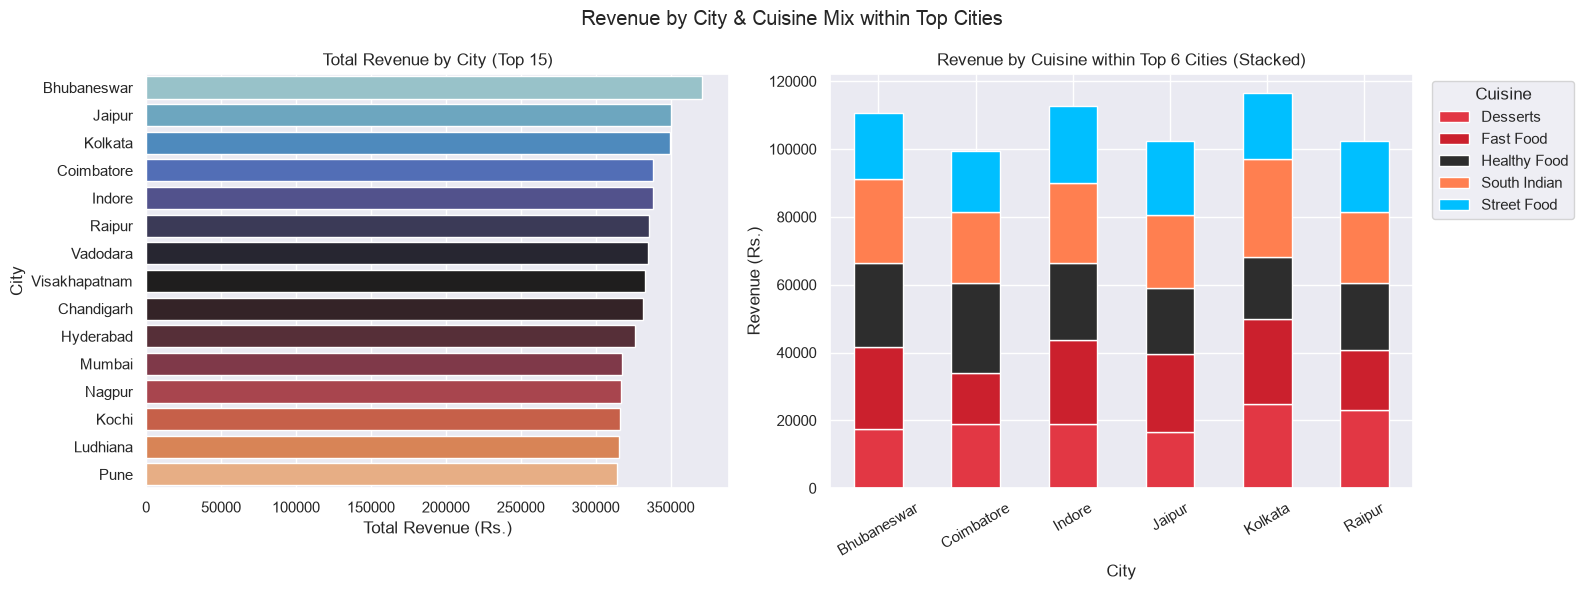

In [97]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Revenue by City & Cuisine Mix within Top Cities")

o_city = orders.merge(customers[['CustomerID', 'City']], on='CustomerID', how='left')
rev_by_city = o_city.groupby('City')['FinalAmount'].sum().sort_values(ascending=False)

sns.barplot(
    x=rev_by_city.head(15).values, 
    y=rev_by_city.head(15).index, 
    palette= 'icefire', 
    ax=axes[0])
axes[0].set_title('Total Revenue by City (Top 15)')
axes[0].set_xlabel('Total Revenue (Rs.)')

rest_c = restaurants[['RestaurantID', 'Cuisine']].copy()
rest_c['RestaurantID'] = rest_c['RestaurantID'].astype(str)
o_cuisine_city = o_city.copy()
o_cuisine_city['RestaurantID'] = o_cuisine_city['RestaurantID'].astype(str)
o_cuisine_city = o_cuisine_city.merge(rest_c, on='RestaurantID', how='left')
top6_cities = rev_by_city.head(6).index.tolist()
top5_cuisines = o_cuisine_city.groupby('Cuisine')['FinalAmount'].sum().nlargest(5).index.tolist()
pivot = o_cuisine_city[
    o_cuisine_city['City'].isin(top6_cities) & o_cuisine_city['Cuisine'].isin(top5_cuisines)
].pivot_table(index='City', columns='Cuisine', values='FinalAmount', aggfunc='sum', fill_value=0)

pivot.plot(
    kind='bar', 
    stacked=True, 
    ax=axes[1], 
    color=sns.color_palette([ZOMATO_RED, ZOMATO_DARK_RED, CHARCOAL, 'coral', 'deepskyblue']))
axes[1].set_title('Revenue by Cuisine within Top 6 Cities (Stacked)')
axes[1].set_xlabel('City')
axes[1].set_ylabel('Revenue (Rs.)')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(title='Cuisine', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()


City-level revenue is a fairly narrow band (Rs. 2.88L-3.71L) - no single city dominates. The cuisine mix within top cities does vary though: Kolkata leans South Indian/Desserts, Coimbatore leans Healthy Food, Jaipur is comparatively light on Healthy Food - useful for city-specific restaurant partnership pushes.

### Revenue & Delivery Time Trends Over Time

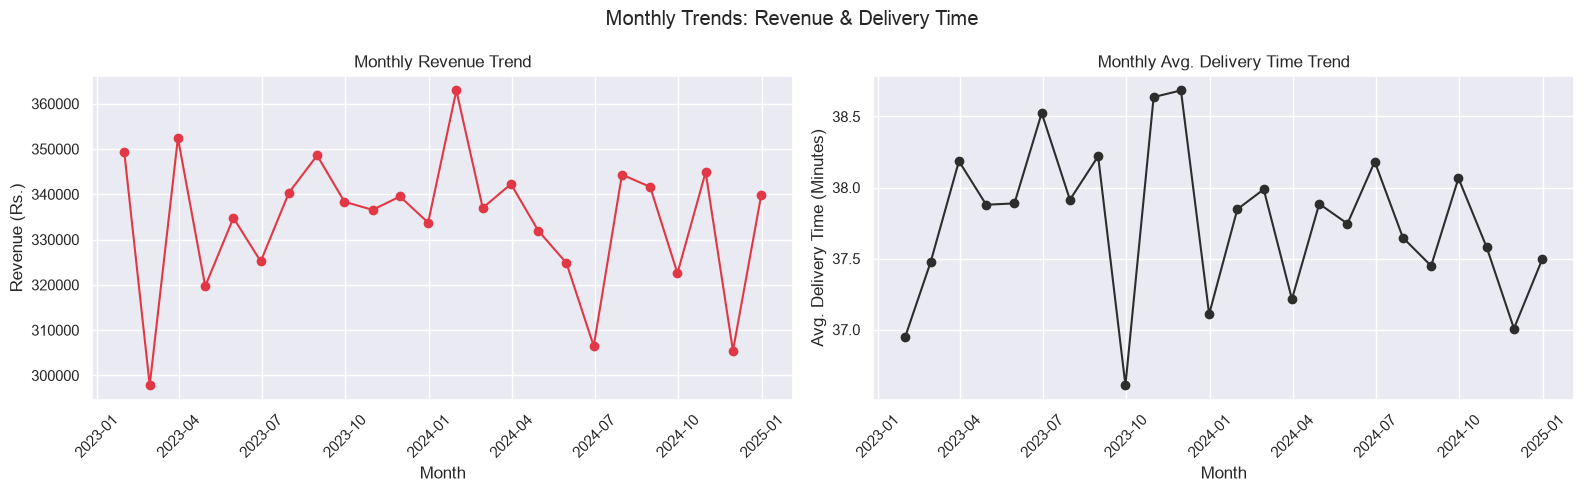

In [98]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Monthly Trends: Revenue & Delivery Time")

monthly_rev = orders.set_index('OrderDate').resample('ME')['FinalAmount'].sum()
monthly_dt = orders.set_index('OrderDate').resample('ME')['DeliveryTimeMinutes'].mean()

axes[0].plot(monthly_rev.index, monthly_rev.values, marker='o', color=ZOMATO_RED)
axes[0].set_title('Monthly Revenue Trend')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Revenue (Rs.)')
axes[0].tick_params(axis='x', rotation=45)

axes[1].plot(monthly_dt.index, monthly_dt.values, marker='o', color=CHARCOAL)
axes[1].set_title('Monthly Avg. Delivery Time Trend')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Avg. Delivery Time (Minutes)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


Output : 
- Monthly revenue trend : Reached a high of over 3.60L rupees around February 2024 but experienced sharp drops near February 2023 (~2.9L rupees) and mid-to-late 2024 (~3.05L–3.06L rupees). Overall pattern shows high volatility month-to-month, typically fluctuating between 3,20,000 rupees and 3,50,000 rupees without a clear long-term upward or downward trend.
- Monthly avg. Delivery time trend: Highest delivery times occurred around late 2023 (October–November), peaking near 38.7 minutes. Reached a minimum of around 36.6 minutes around October 2023. Ranges mainly between 37.0 and 38.7 minutes, featuring sharp fluctuations throughout the timeline.

### Cumulative Revenue Growth

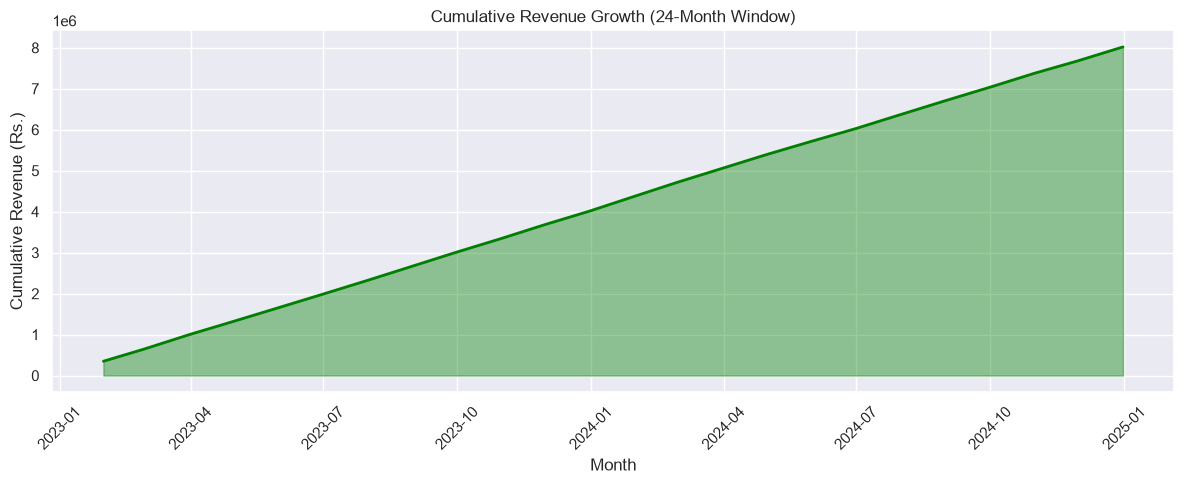

Total revenue over the full window: Rs. 8,020,380.10


In [99]:
monthly_rev = orders.set_index('OrderDate').resample('ME')['FinalAmount'].sum()
cumulative_rev = monthly_rev.cumsum()

plt.figure(figsize=(12, 5))
plt.fill_between(cumulative_rev.index, cumulative_rev.values, color='green', alpha=0.4)
plt.plot(cumulative_rev.index, cumulative_rev.values, color='green', linewidth=2)
plt.title('Cumulative Revenue Growth (24-Month Window)')
plt.xlabel('Month')
plt.ylabel('Cumulative Revenue (Rs.)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f'Total revenue over the full window: Rs. {cumulative_rev.iloc[-1]:,.2f}')


Output : A near-straight-line climb to Rs. 80.2L total over 24 months which shows a steady, near-linear upward trajectory throughout the entire 2-year period.

### Delivery Time by Vehicle Type & by City

/var/folders/14/vwm12jsj6k54dqpcrph9h29w0000gp/T/ipykernel_91746/544890385.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


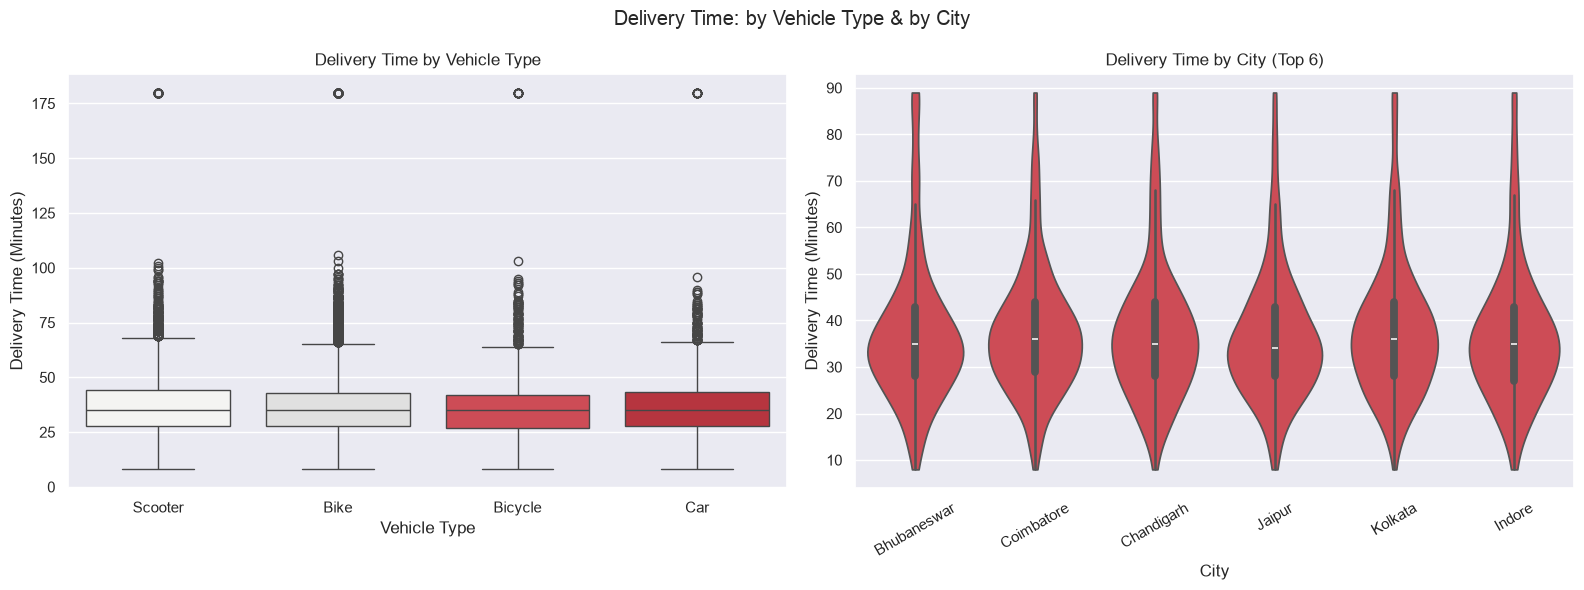

             mean  median
VehicleType              
Bicycle      37.3    35.0
Bike         37.8    35.0
Car          37.7    35.0
Scooter      37.9    35.0


In [100]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Delivery Time: by Vehicle Type & by City")

sns.boxplot(
    data=orders_dp,
    x='VehicleType',
    y='DeliveryTimeMinutes',
    palette=[NEUTRAL_BOX, NEUTRAL_GREY, ZOMATO_RED, ZOMATO_DARK_RED],
    ax=axes[0],
)
axes[0].set_title('Delivery Time by Vehicle Type')
axes[0].set_xlabel('Vehicle Type')
axes[0].set_ylabel('Delivery Time (Minutes)')

top_cities_violin = orders_tw['City'].value_counts().head(6).index.tolist()
sns.violinplot(
    data=orders_tw[orders_tw['City'].isin(top_cities_violin)],
    x='City',
    y='DeliveryTimeCapped',
    color=ZOMATO_RED,
    cut=0,
    ax=axes[1],
)
axes[1].set_title('Delivery Time by City (Top 6)')
axes[1].set_xlabel('City')
axes[1].set_ylabel('Delivery Time (Minutes)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

print(orders_dp.groupby('VehicleType')['DeliveryTimeMinutes'].agg(['mean','median']).round(1))


Output : 
- Vehicle type makes almost no difference (37.3-37.9 min mean across Bicycle/Bike/Car/Scooter). Every vehicle type experiences occasional delivery delays stretching past 75 minutes, with extreme outliers hitting around 180 minutes.
- The violin view of delivery time by city says each city displays a similar spread, with minimum delivery times starting near 10 minutes and long tails stretching up to 90 minutes.

### Payment Method Usage

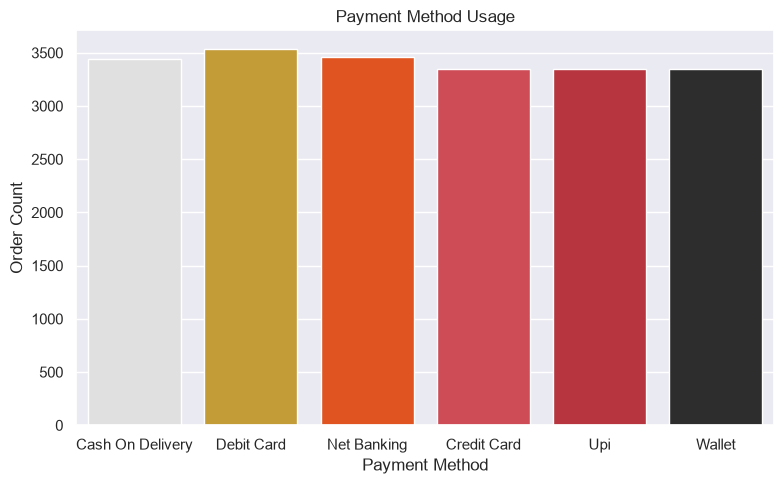

In [101]:
plt.figure(figsize=(8, 5))
sns.countplot(
    data=orders, 
    x='PaymentMethod', 
    hue='PaymentMethod', 
    palette=[NEUTRAL_GREY,'goldenrod','orangered',ZOMATO_RED,ZOMATO_DARK_RED,CHARCOAL], 
    legend=False)
plt.title('Payment Method Usage')
plt.xlabel('Payment Method')
plt.ylabel('Order Count')
#plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


Output : All payment methods show similar distribution with no anomalies. 